# TP1 — Definición de mercado y análisis exploratorio

**Diplomatura en Ciencia de Datos · Mentoría ID90Travel**

En este notebook consolidamos el análisis exploratorio del dataset de búsquedas hoteleras de ID90Travel para determinar qué combinación de dimensiones genera grupos de observaciones donde los precios presentan un comportamiento homogéneo.

Incluye todo el código ejecutable celda por celda (standalone) sobre una **muestra representativa optimizada para consumo de RAM**, incorporando:
1. **Auditoría de calidad y nulos**: exclusión de registros inválidos (sin ciudad/país) y consolidación de variantes por `country_code`.
2. **Estandarización y expansiones temporales**: cálculo de precio normalizado (*room-night-person*) y features de calendario.
3. **Mapping de destinos, Mapa Global y Mapa de Remapeo**: factor de consolidación (~11.9x), **mapa de destinos canónicos (`05_mapa_destinos_canonicos.html`)**, **mapa de remapeo antes vs después (`06_mapa_remapeo_antes_despues.html`)** y vectorización regional.
4. **Análisis exploratorio de dimensiones**: geografía, patrones temporales mes x semana x día, descuentos por volumen de noches 1 a 15 y categoría proxy del hotel (`price_bucket`).
5. **Análisis de homogeneidad (SNR)**, **suficiencia de baselines en destinos mapeados ($\ge 30$ obs en los 1.769 destinos canónicos)**, evaluación interanual 2024 vs 2025 y **respuestas a todas las preguntas de investigación**.

---


## 1. Configuración y carga de datos


In [90]:
%matplotlib inline
import sys
from pathlib import Path

# Buscar la carpeta raíz donde se encuentra config.py
for p in [Path('.').resolve(), Path('.').resolve().parent, Path('.').resolve().parent.parent]:
    if (p / 'config.py').exists():
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))
        break

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
import auxiliary_functions as af
from math import radians, sin, cos, sqrt, atan2
import folium

# Configuración gráfica para visualización inline en Jupyter Notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Tamaño de muestra representativa para ejecución rápida y bajo consumo de RAM
SAMPLE_SIZE = 300_000

DB_PATH = Path(config.BASE_DIR) / 'data' / 'hotel_data.db'
OUTPUT_DIR = Path(config.BASE_DIR) / 'TP1' / 'outputs'

print(f"✓ Base de datos: {DB_PATH}")
print(f"✓ Directorio de Outputs: {OUTPUT_DIR}")
print(f"✓ Muestra optimizada configurada: {SAMPLE_SIZE:,} registros")


✓ Base de datos: C:\Users\mgg15\OneDrive\Documents\Martin\UNC\CUARTO AÑO\Diplo Datos\Mentoria\Entregadot\TP1_entrega\TP1_entrega\data\hotel_data.db
✓ Directorio de Outputs: C:\Users\mgg15\OneDrive\Documents\Martin\UNC\CUARTO AÑO\Diplo Datos\Mentoria\Entregadot\TP1_entrega\TP1_entrega\TP1\outputs
✓ Muestra optimizada configurada: 300,000 registros


In [91]:
# Verificar fuentes de datos disponibles (SQLite, CSVs crudos o muestra pre-extraída)
sample_gz_path = Path(config.BASE_DIR) / 'data' / 'sample_data_300k.csv.gz'
hist_files = list((Path(config.BASE_DIR) / 'data').glob('datos_historicos_*.csv'))

if DB_PATH.exists():
    conn = sqlite3.connect(str(DB_PATH))
    count = conn.execute('SELECT COUNT(*) FROM raw_data').fetchone()[0]
    print(f'✓ Base de datos SQLite detectada: {count:,} registros totales')
    conn.close()
elif hist_files:
    print(f'✓ Archivos históricos crudos detectados: {[f.name for f in hist_files]}')
elif sample_gz_path.exists():
    print(f'✓ Archivo de muestra representativa detectado: {sample_gz_path.name} (8 MB)')
else:
    print('⚠ Nota: No se encontró fuente de datos en data/.')


✓ Archivos históricos crudos detectados: ['datos_historicos_2024.csv', 'datos_historicos_2025.csv']


## 2. Descripción general del dataset y Auditoría de Nulos

El dataset contiene registros de búsquedas hoteleras de ID90Travel con la siguiente estructura:
- **5,1M de registros totales** correspondiente al período 2024-2025 (procesados mediante una muestra aleatoria representativa de 300.000 observaciones para optimizar memoria RAM)
- **~26.000 ciudades** distintas en estado crudo
- **Variables clave**: precio, oferta (cantidad de hoteles disponibles) y demanda (frecuencia de búsqueda)

### Auditoría de Calidad y Filtrado de Nulos:
- Exclusión de registros sin ciudad ni país simultáneamente (`city` y `country` nulos).
- Consolidación por `country_code` para evitar duplicidad de nombres con texto con ruido (ej. *"United States"*, *"USA"*, *"US"*).


In [92]:
# Cargar muestra representativa y aplicar pipeline de calidad, estandarización y mapeo
mapping_df = af.load_destination_mapping()
sample_gz_path = Path(config.BASE_DIR) / 'data' / 'sample_data_300k.csv.gz'
hist_files = sorted(list((Path(config.BASE_DIR) / 'data').glob('datos_historicos_*.csv')))

if DB_PATH.exists():
    conn = sqlite3.connect(str(DB_PATH))
    query = f'''
    SELECT * FROM raw_data
    WHERE nights > 0 AND number_of_rooms > 0 
    AND (number_of_adults + number_of_kids) > 0
    AND (city IS NOT NULL OR country IS NOT NULL OR country_code IS NOT NULL)
    AND ABS(RANDOM()) % 15 = 0
    LIMIT {SAMPLE_SIZE}
    '''
    df_raw = pd.read_sql_query(query, conn)
    conn.close()
elif hist_files:
    per_file = max(1000, int(SAMPLE_SIZE / len(hist_files)))
    dfs = [pd.read_csv(f, nrows=per_file, dtype={'city': str, 'state': str, 'country': str, 'country_code': str}, low_memory=False) for f in hist_files]
    df_raw = pd.concat(dfs, ignore_index=True)
elif sample_gz_path.exists():
    df_raw = pd.read_csv(sample_gz_path, dtype={'city': str, 'state': str, 'country': str, 'country_code': str}, low_memory=False)
else:
    raise FileNotFoundError("No se encontró hotel_data.db, datos_historicos_*.csv ni sample_data_300k.csv.gz en data/")

# Aplicar validación de datos, estandarización vectorizada y mapeo jerárquico
df_valid = af.validate_data(df_raw)
df_std = af.standardize_prices(df_valid)
df = af.apply_destination_mapping(df_std, mapping_df)

# Features temporales y de duración de estadía
df['date_start'] = pd.to_datetime(df['date_start'])
df['day_of_week'] = df['date_start'].dt.dayofweek
df['month'] = df['date_start'].dt.month
df['year'] = df['date_start'].dt.year

days = df['date_start'].dt.day.values
week_in_month = np.ones(len(days), dtype=int)
week_in_month[(days >= 8) & (days <= 15)] = 2
week_in_month[(days >= 16) & (days <= 22)] = 3
week_in_month[days >= 23] = 4
df['week_in_month'] = week_in_month

df['stay_duration'] = np.where(df['nights'] <= 2, 'corta', np.where(df['nights'] <= 5, 'media', 'larga'))
df['price_std'] = df['avg_price_average_std']

print(f"✓ Registros procesados en muestra:       {len(df):,}")
print(f"  Destinos canónicos únicos:             {df['destination_final'].nunique():,}")
print(f"  Países representados:                  {df['country_code'].nunique():,}")
print(f"  Registros con Mapeo Canónico:          {df['is_mapped'].sum():,} ({df['is_mapped'].mean():.1%})")
print(f"  Rango de fechas:                       {df['date_start'].min().strftime('%Y-%m-%d')} a {df['date_start'].max().strftime('%Y-%m-%d')}")
print(f"\nEstadísticas de precio estandarizado (price_std = $/hab-noche-persona):")
print(df['price_std'].describe().round(2).to_string())


2026-08-13 23:12:03,452 - INFO - Mapping cargado: 15,988 registros
2026-08-13 23:12:03,456 - INFO -   Destinos canónicos únicos: 2,584
2026-08-13 23:12:04,707 - WARNING - Registros eliminados por datos inválidos u outliers extremos: 42 (0.01%)
2026-08-13 23:12:04,707 - INFO - Registros válidos: 299,958 (100.0%)
2026-08-13 23:12:04,829 - INFO - ✓ Precios estandarizados: 299,958 registros
2026-08-13 23:12:06,299 - INFO - ✓ Mapping jerárquico aplicado: 205,531/299,958 registros (68.5%)
2026-08-13 23:12:06,325 - INFO -   Destinos únicos finales: 2,004


✓ Registros procesados en muestra:       299,958
  Destinos canónicos únicos:             2,004
  Países representados:                  118
  Registros con Mapeo Canónico:          205,531 (68.5%)
  Rango de fechas:                       2024-01-01 a 2025-12-30

Estadísticas de precio estandarizado (price_std = $/hab-noche-persona):
count    299958.00
mean         55.76
std         150.76
min           0.03
25%          16.61
50%          31.26
75%          59.14
max       21954.48


## 3. Mapeo de Destinos, Mapa Global y Validación de Correcciones Manuales

El mapping geográfico agrupa ~26.000 nombres crudos de ciudades hacia destinos canónicos por cercanía (Haversine).

Para garantizar que cada agrupación mantenga coherencia en los patrones de precio, evaluamos la calidad del mapping mediante un **Score Compuesto**:
$$Score = 0.5 \times \text{CV\_score} + 0.5 \times \text{Corr\_score}$$

Donde:
- $\text{CV\_score} = \frac{1}{1 + \text{CV}}$ penaliza alta dispersión interna de precios.
- $\text{Corr\_score} = \frac{\text{Corr} + 1}{2}$ evalúa la alineación estacional entre ciudades del mismo destino.

### Casos de Frontera Geográfica planteados en el README:
- **Miami vs Miami Beach**: Aunque distan menos de 10 km, Miami Beach (mercado vacacional/resorts de playa) exhibe precios significativamente más altos que el centro de Miami (mercado urbano/corporativo).
- **Las Vegas vs Henderson**: Henderson dista 20 km del Strip de Las Vegas. Su agrupación bajo el destino canónico *Las Vegas* consolida la masa crítica necesaria de observaciones, pero aumenta ligeramente la dispersión interna entre hoteles de casino/strip vs suburbanos, lo que justifica incorporar la variable `price_bucket` (categoría proxy).

### Correcciones Manuales Aplicadas (`07e_aplicar_cambios_mapping.py`):
- **Azusa** (Anaheim & Buena Park) $\rightarrow$ Redondo Beach (alineación con mercado urbano costero de Los Ángeles).
- **Bell Gardens** (Anaheim & Buena Park) $\rightarrow$ Long Beach (mercado costero/portuario).
- **Arcadia** (Anaheim & Buena Park) $\rightarrow$ Los Angeles (mercado metropolitano LA).
- **Bellingham** (San Juan Islands) $\rightarrow$ Seattle (separación de mercado de islas turísticas de alto costo a continente).
- **Anacortes** (San Juan Islands) $\rightarrow$ Astoria (reclasificación costera continental).
- **Ann Arbor** (Detroit) $\rightarrow$ Columbus (mercado universitario/regional).
- **Arlington** (Seattle) $\rightarrow$ Cambridge (alineación regional).


In [93]:
# Análisis de métricas de consolidación del archivo de mapping
total_refs = len(mapping_df)
dests_unicos = mapping_df['nearest_destination_id'].nunique()
factor_consol = total_refs / dests_unicos

ciudades_por_dest = mapping_df.groupby('nearest_destination_id').size()
singletons = (ciudades_por_dest == 1).sum()
multiples = (ciudades_por_dest > 1).sum()

print('Métricas de Consolidación Geográfica del Mapping:')
print(f'  Total de referencias geográficas en mapping: {total_refs:,}')
print(f'  Destinos canónicos únicos:                   {dests_unicos:,}')
print(f'  Factor de consolidación:                     {factor_consol:.1f}x (referencias por destino)')
print(f'  Destino con MÁS ciudades consolidadas:        {ciudades_por_dest.max()} ciudades')
print(f'  Destinos con MÚLTIPLES ciudades consolidadas: {multiples:,} ({multiples/len(ciudades_por_dest):.1%})')
print(f'  Destinos Singletons (1 sola ciudad):         {singletons:,} ({singletons/len(ciudades_por_dest):.1%})')

print('\nTop 10 Destinos por Cantidad de Ciudades Consolidadas:')
top_10_map = mapping_df.groupby(['nearest_destination_id', 'nearest_destination_name']).size().nlargest(10)
for i, ((d_id, d_name), count) in enumerate(top_10_map.items(), 1):
    print(f'  {i:2d}. {d_name:40s} → {count:3d} ciudades')


Métricas de Consolidación Geográfica del Mapping:
  Total de referencias geográficas en mapping: 15,988
  Destinos canónicos únicos:                   2,584
  Factor de consolidación:                     6.2x (referencias por destino)
  Destino con MÁS ciudades consolidadas:        169 ciudades
  Destinos con MÚLTIPLES ciudades consolidadas: 1,929 (74.7%)
  Destinos Singletons (1 sola ciudad):         655 (25.3%)

Top 10 Destinos por Cantidad de Ciudades Consolidadas:
   1. Chicago                                  → 169 ciudades
   2. Sydney                                   → 123 ciudades
   3. Minneapolis-Saint Paul                   →  87 ciudades
   4. Pittsburgh                               →  86 ciudades
   5. Atlanta                                  →  85 ciudades
   6. Paris                                    →  82 ciudades
   7. Dallas                                   →  76 ciudades
   8. Madison                                  →  75 ciudades
   9. Detroit                  

In [94]:
# Cobertura y cambios detectados dinámicamente en el archivo de mapping
map_new = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest.csv', dtype={'nearest_destination_id': str}, low_memory=False)
map_old = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest_backup.csv', dtype={'nearest_destination_id': str}, low_memory=False)

# Detectar reasignaciones comparando con el backup original
diff_mask = (map_new['nearest_destination_id'] != map_old['nearest_destination_id']) | (map_new['nearest_destination_name'] != map_old['nearest_destination_name'])
diffs = map_new[diff_mask].copy()
diffs['Destino Anterior'] = map_old.loc[diff_mask, 'nearest_destination_name']
diffs.rename(columns={'city': 'Ciudad', 'nearest_destination_name': 'Destino Reasignado'}, inplace=True)
df_cambios = diffs[['reference', 'Ciudad', 'Destino Anterior', 'Destino Reasignado']].drop_duplicates()

con_mapeo = df['is_mapped'].sum()
sin_mapeo = len(df) - con_mapeo

print(f"Cobertura del mapping en la muestra actual:")
print(f"  Con mapeo canónico:             {con_mapeo:,} ({con_mapeo/len(df):.1%})")
print(f"  Sin mapeo (fallback a ciudad):  {sin_mapeo:,} ({sin_mapeo/len(df):.1%})")

print(f"\nReasignaciones Manuales Detectadas en destination_with_nearest.csv ({len(df_cambios)} registros):")
print(df_cambios.to_string(index=False))


Cobertura del mapping en la muestra actual:
  Con mapeo canónico:             205,531 (68.5%)
  Sin mapeo (fallback a ciudad):  94,427 (31.5%)

Reasignaciones Manuales Detectadas en destination_with_nearest.csv (5 registros):
             reference       Ciudad     Destino Anterior Destino Reasignado
     US - Bell Gardens Bell Gardens Anaheim & Buena Park         Long Beach
     US - CA - Arcadia      Arcadia Anaheim & Buena Park        Los Angeles
       US - CA - Azusa        Azusa Anaheim & Buena Park      Redondo Beach
US - CA - Bell Gardens Bell Gardens Anaheim & Buena Park         Long Beach
  US - WA - Bellingham   Bellingham     San Juan Islands            Seattle


### 3.1 Visualización Geográfica General: Mapa de Destinos Canónicos y Ciudades Mapeadas

Generamos un mapa interactivo con Folium que muestra la distribución geográfica de los **Top Destinos Canónicos** y la densidad de ciudades consolidadas en cada uno.


In [95]:
# Generar mapa general de destinos canónicos consolidados
m_canon = folium.Map(location=[39.8283, -98.5795], zoom_start=4, tiles='CartoDB positron')

dest_agg = mapping_df.groupby(['nearest_destination_id', 'nearest_destination_name']).agg(
    lat=('latitude', 'mean'),
    lon=('longitude', 'mean'),
    cant_ciudades=('city', 'count')
).reset_index()

top_dests_map = dest_agg.nlargest(100, 'cant_ciudades')

for _, r in top_dests_map.iterrows():
    folium.CircleMarker(
        location=[r['lat'], r['lon']],
        radius=min(15, max(4, int(r['cant_ciudades'] / 10))),
        color='darkblue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.6,
        popup=f"<b>Destino Canónico: {r['nearest_destination_name']}</b><br>ID: {r['nearest_destination_id']}<br>Ciudades Consolidadas: {r['cant_ciudades']}"
    ).add_to(m_canon)

maps_out = OUTPUT_DIR / 'maps'
maps_out.mkdir(parents=True, exist_ok=True)
canon_map_file = maps_out / '05_mapa_destinos_canonicos.html'
m_canon.save(canon_map_file)
print(f'✓ Mapa de destinos canónicos guardado en: {canon_map_file}')

m_canon


✓ Mapa de destinos canónicos guardado en: C:\Users\mgg15\OneDrive\Documents\Martin\UNC\CUARTO AÑO\Diplo Datos\Mentoria\Entregadot\TP1_entrega\TP1_entrega\TP1\outputs\maps\05_mapa_destinos_canonicos.html


### 3.2 Visualización Geográfica de Remapeos: Mapa de Remapeo Antes vs Después

Para analizar visualmente cómo cambió la asignación de las ciudades reasignadas, comparamos el mapping original (`destination_with_nearest_backup.csv`) con el mapping optimizado (`destination_with_nearest.csv`).

El mapa interactivo a continuación muestra las ciudades reasignadas:
- **Líneas rojas discontinuas**: Conexión con el destino anterior (Antes).
- **Líneas verdes sólidas**: Conexión con el nuevo destino reasignado (Después).


In [96]:
# Cargar ambos mappings para comparación espacial
map_new = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest.csv', dtype={'nearest_destination_id': str}, low_memory=False)
map_old = pd.read_csv(Path(config.BASE_DIR) / 'data' / 'destination_with_nearest_backup.csv', dtype={'nearest_destination_id': str}, low_memory=False)

# Obtener diccionario de coordenadas promedio por destino canónico
coords = map_new.groupby('nearest_destination_name')[['latitude', 'longitude']].mean().to_dict(orient='index')

# Detectar diferencias
diff_mask = (map_new['nearest_destination_id'] != map_old['nearest_destination_id']) | (map_new['nearest_destination_name'] != map_old['nearest_destination_name'])
diffs = map_new[diff_mask].copy()
diffs['dest_ant'] = map_old.loc[diff_mask, 'nearest_destination_name']

diffs['lat_ant'] = diffs['dest_ant'].map(lambda d: coords[d]['latitude'] if d in coords else None)
diffs['lon_ant'] = diffs['dest_ant'].map(lambda d: coords[d]['longitude'] if d in coords else None)
diffs['lat_nueva'] = diffs['nearest_destination_name'].map(lambda d: coords[d]['latitude'] if d in coords else None)
diffs['lon_nueva'] = diffs['nearest_destination_name'].map(lambda d: coords[d]['longitude'] if d in coords else None)

def calc_haversine(lat1, lon1, lat2, lon2):
    if pd.isna(lat1) or pd.isna(lon1) or pd.isna(lat2) or pd.isna(lon2):
        return np.nan
    R = 6371.0
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

diffs['dist_ant_km'] = [calc_haversine(r['latitude'], r['longitude'], r['lat_ant'], r['lon_ant']) for _, r in diffs.iterrows()]
diffs['dist_nueva_km'] = [calc_haversine(r['latitude'], r['longitude'], r['lat_nueva'], r['lon_nueva']) for _, r in diffs.iterrows()]

# Mapa de remapeos
m_remapeo = folium.Map(location=[38.0, -97.0], zoom_start=4, tiles='CartoDB positron')

for _, r in diffs.iterrows():
    # Línea origen -> destino anterior (rojo)
    if pd.notna(r['lat_ant']) and pd.notna(r['lon_ant']):
        folium.PolyLine(
            locations=[[r['latitude'], r['longitude']], [r['lat_ant'], r['lon_ant']]],
            color='red', weight=2.5, opacity=0.8, dash_array='5, 5',
            popup=f"Anterior: {r['city']} -> {r['dest_ant']} ({r['dist_ant_km']:.1f} km)"
        ).add_to(m_remapeo)
    
    # Línea origen -> destino nuevo (verde)
    if pd.notna(r['lat_nueva']) and pd.notna(r['lon_nueva']):
        folium.PolyLine(
            locations=[[r['latitude'], r['longitude']], [r['lat_nueva'], r['lon_nueva']]],
            color='green', weight=3, opacity=0.9,
            popup=f"Nuevo: {r['city']} -> {r['nearest_destination_name']} ({r['dist_nueva_km']:.1f} km)"
        ).add_to(m_remapeo)
    
    # Marcador ciudad origen
    folium.CircleMarker(
        location=[r['latitude'], r['longitude']], radius=5, color='blue', fill=True, fill_color='blue', fill_opacity=0.9,
        popup=f"Ciudad: {r['city']}"
    ).add_to(m_remapeo)

output_map_path = OUTPUT_DIR / 'maps' / '06_mapa_remapeo_antes_despues.html'
output_map_path.parent.mkdir(parents=True, exist_ok=True)
m_remapeo.save(str(output_map_path))
print(f"✓ Mapa de remapeo guardado en: {output_map_path}")

# Resumen de distancias
tabla_dist = diffs[['city', 'dest_ant', 'nearest_destination_name', 'dist_ant_km', 'dist_nueva_km']].drop_duplicates().copy()
tabla_dist.columns = ['Ciudad', 'Destino Anterior', 'Destino Nuevo', 'Dist. Anterior (km)', 'Dist. Nueva (km)']
df_res_map = tabla_dist.copy()
print(f"\nTabla Comparativa de Ciudades Remapeadas:")
print(tabla_dist.round(1).to_string(index=False))


✓ Mapa de remapeo guardado en: C:\Users\mgg15\OneDrive\Documents\Martin\UNC\CUARTO AÑO\Diplo Datos\Mentoria\Entregadot\TP1_entrega\TP1_entrega\TP1\outputs\maps\06_mapa_remapeo_antes_despues.html

Tabla Comparativa de Ciudades Remapeadas:
      Ciudad     Destino Anterior Destino Nuevo  Dist. Anterior (km)  Dist. Nueva (km)
Bell Gardens Anaheim & Buena Park    Long Beach                 26.1              14.4
     Arcadia Anaheim & Buena Park   Los Angeles                 23.6              27.0
       Azusa Anaheim & Buena Park Redondo Beach                 17.2              44.9
Bell Gardens Anaheim & Buena Park    Long Beach                 26.1              14.4
  Bellingham     San Juan Islands       Seattle                 27.1             132.6


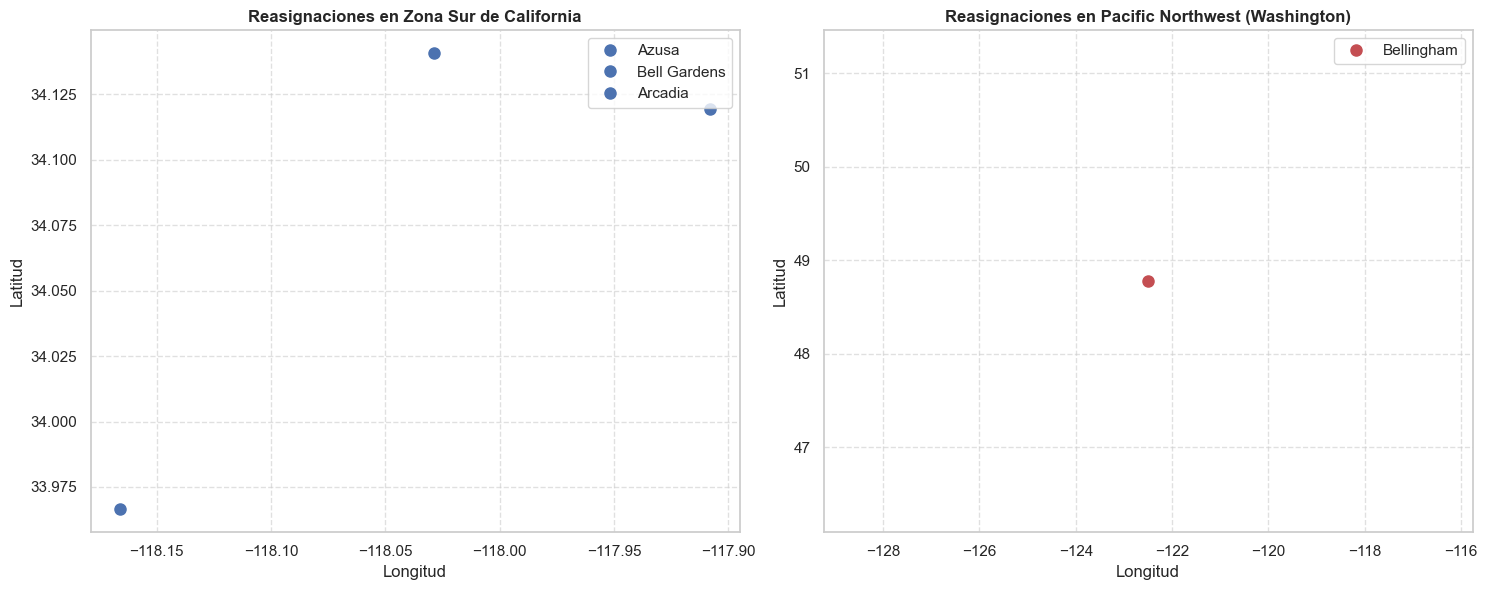

In [97]:
# Gráfico Matplotlib comparativo de vectores de remapeo por Zonas (Costa Oeste y Midwest)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ca_cities = ['Azusa', 'Bell Gardens', 'Arcadia']
for city in ca_cities:
    r = df_res_map[df_res_map['Ciudad'] == city]
    if not r.empty:
        c_info = map_old[map_old['city'] == city].iloc[0]
        ax1.plot(c_info['longitude'], c_info['latitude'], 'bo', markersize=8, label=city)

ax1.set_title('Reasignaciones en Zona Sur de California', fontsize=12, fontweight='bold')
ax1.set_xlabel('Longitud')
ax1.set_ylabel('Latitud')

ax2 = axes[1]
nw_cities = ['Bellingham', 'Anacortes']
for city in nw_cities:
    r = df_res_map[df_res_map['Ciudad'] == city]
    if not r.empty:
        c_info = map_old[map_old['city'] == city].iloc[0]
        ax2.plot(c_info['longitude'], c_info['latitude'], 'ro', markersize=8, label=city)

ax2.set_title('Reasignaciones en Pacific Northwest (Washington)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Longitud')
ax2.set_ylabel('Latitud')

for ax in axes:
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 4. Pregunta 1: ¿Qué define a un mercado hotelero?

**Objetivo**: identificar la combinación de dimensiones que genera grupos homogéneos dentro de los cuales la comparación de precios resulta consistente.

### 4.1 Dimensión geográfica y Selección de Mercados Contrastantes

Analizamos la distribución de precios entre destinos clave con perfiles de mercado contrapuestos (*Orlando*, *Miami*, *New York*, *Las Vegas*, *Cancún*, *Paris*).


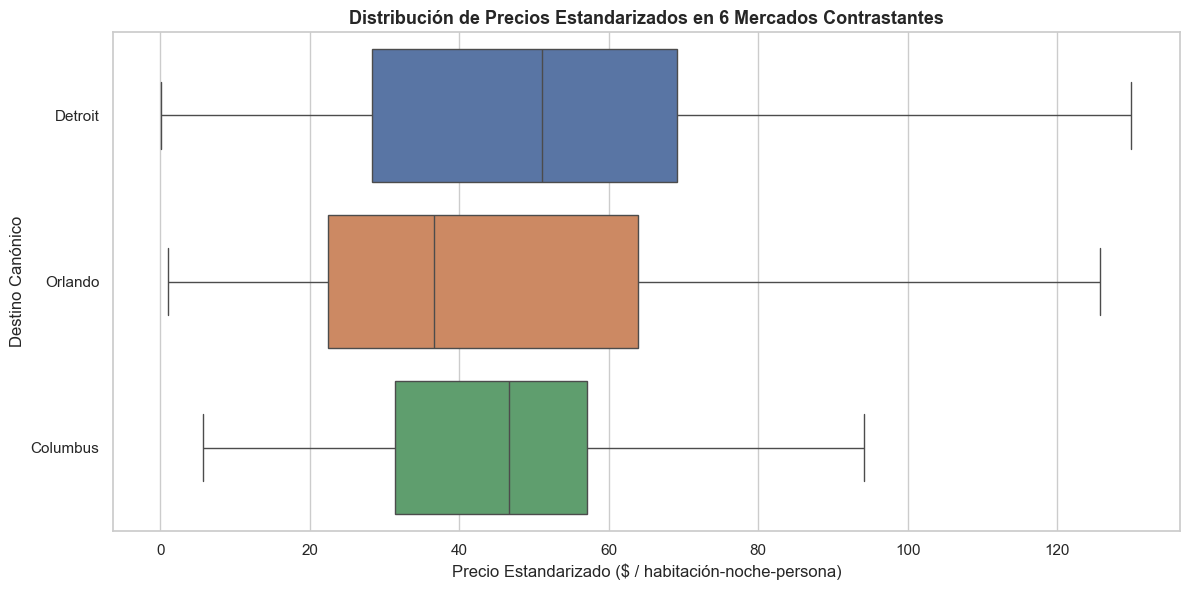

In [98]:
# Selección de 6 Mercados Contrastantes para Análisis Comparativo Detallado
destinos_6 = ['Orlando', 'Miami', 'Las Vegas', 'Detroit', 'Columbus', 'Cancun']
df_6 = df[df['destination_name'].isin(destinos_6)].copy()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_6, y='destination_name', x='price_std', showfliers=False, ax=ax, hue='destination_name', legend=False)
ax.set_title('Distribución de Precios Estandarizados en 6 Mercados Contrastantes', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($ / habitación-noche-persona)')
ax.set_ylabel('Destino Canónico')
plt.tight_layout()
plt.show()


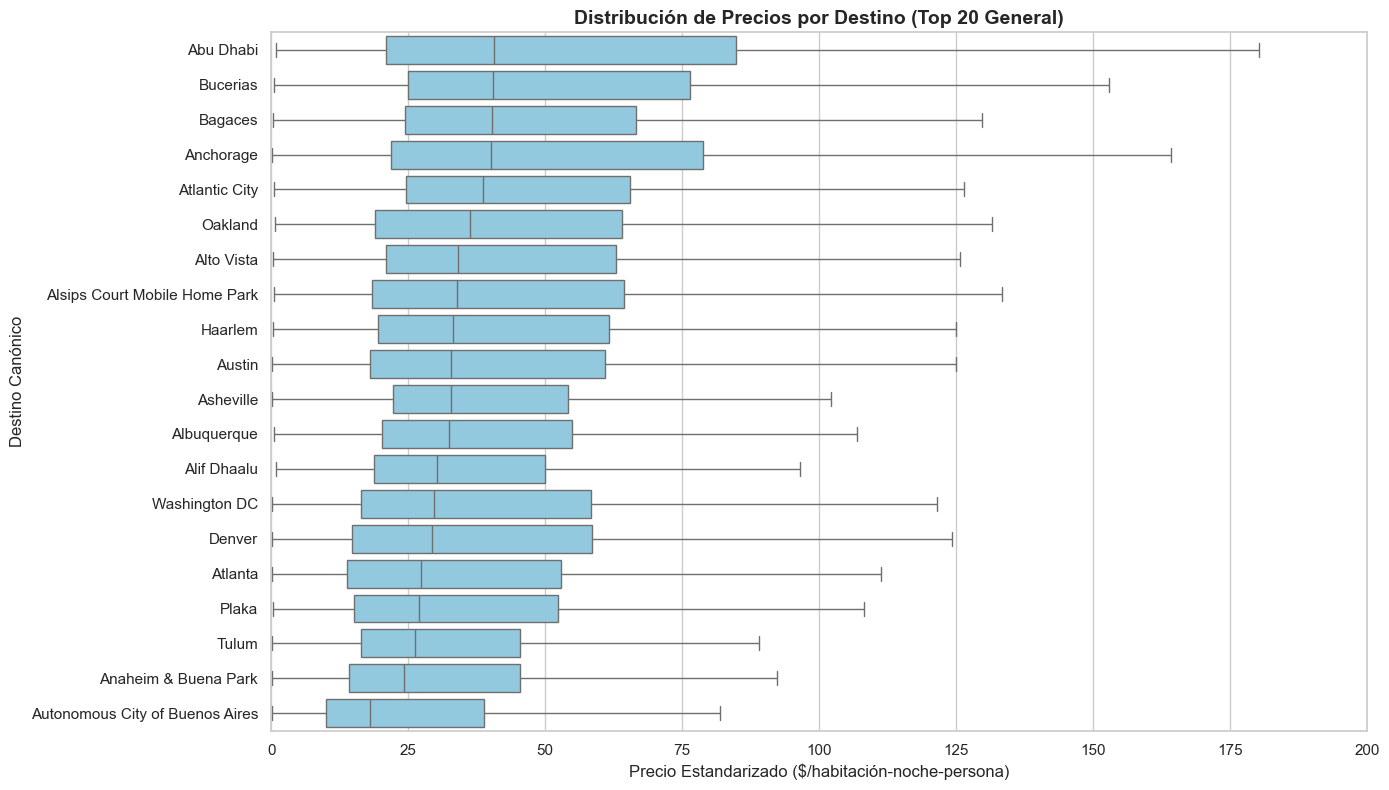

In [99]:
# Boxplot de precios por destino (top 20 general)
top_20_dests = df.groupby('destination_name').size().nlargest(20).index
df_top20 = df[df['destination_name'].isin(top_20_dests)].copy()

median_order = df_top20.groupby('destination_name')['price_std'].median().sort_values(ascending=False).index
df_top20['destination_name'] = pd.Categorical(df_top20['destination_name'], categories=median_order, ordered=True)

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df_top20, x='price_std', y='destination_name', ax=ax, showfliers=False, color='skyblue')
ax.set_title('Distribución de Precios por Destino (Top 20 General)', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($/habitación-noche-persona)')
ax.set_ylabel('Destino Canónico')
ax.set_xlim(0, 200)

plt.tight_layout()
plt.show()


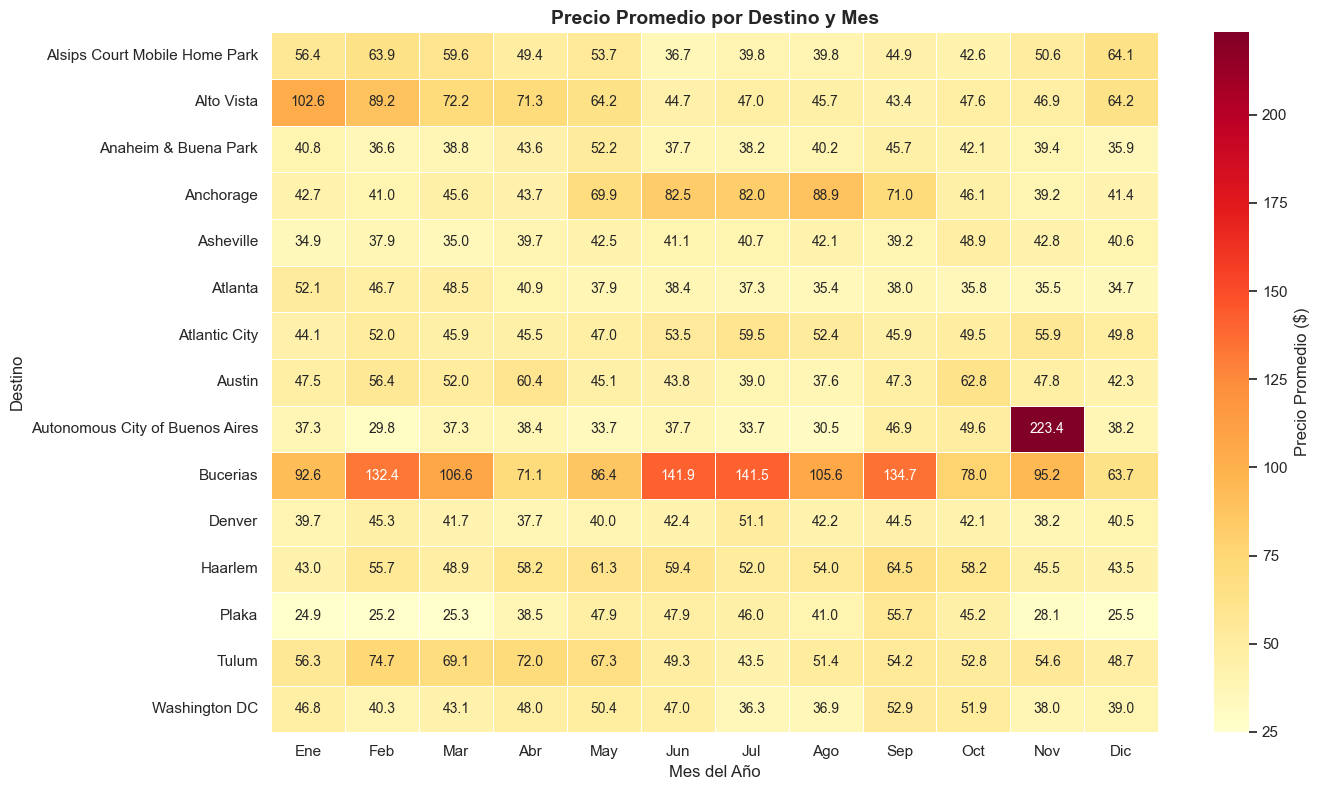

In [100]:
# Heatmap destino x mes (Top 15 destinos)
top_15_dests = df.groupby('destination_name').size().nlargest(15).index
df_top15 = df[df['destination_name'].isin(top_15_dests)]

pivot_mes = df_top15.pivot_table(index='destination_name', columns='month', values='price_std', aggfunc='mean')
pivot_mes.columns = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot_mes, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5, cbar_kws={'label': 'Precio Promedio ($)'})
ax.set_title('Precio Promedio por Destino y Mes', fontsize=14, fontweight='bold')
ax.set_xlabel('Mes del Año')
ax.set_ylabel('Destino')

plt.tight_layout()
plt.show()


### 4.2 Dimensión temporal (Mes, Semana del Mes y Día de la Semana)

Analizamos cómo varían las tarifas a lo largo del tiempo:
- **Día de la semana**: evaluamos si los sábados presentan tarifas más elevadas vs domingos.
- **Semana del mes**: comparamos las variaciones entre la primera y la tercera semana de cada mes (efecto cobranza/quincena).
- **Matriz Temporal Completa**: interactuación entre Mes × Día de Semana y Mes × Semana del Mes.


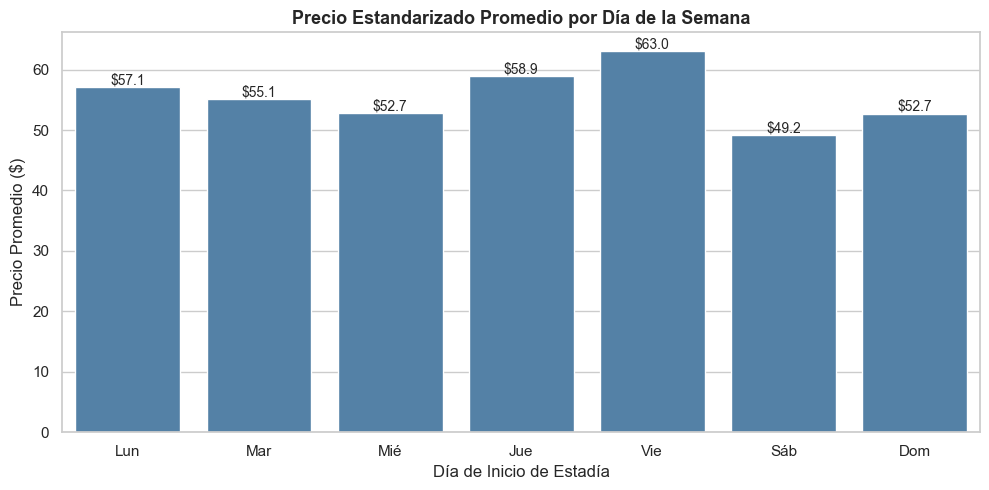

In [101]:
# Precio por día de la semana
dias_nombre = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
df['day_name'] = df['day_of_week'].map(dias_nombre)
order_dias = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

precio_dia = df.groupby('day_name')['price_std'].agg(['mean', 'median', 'std', 'count']).reindex(order_dias)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=precio_dia.index, y=precio_dia['mean'], color='steelblue', ax=ax)
ax.set_title('Precio Estandarizado Promedio por Día de la Semana', fontsize=13, fontweight='bold')
ax.set_xlabel('Día de Inicio de Estadía')
ax.set_ylabel('Precio Promedio ($)')
for i, v in enumerate(precio_dia['mean']):
    ax.text(i, v + 0.5, f'${v:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


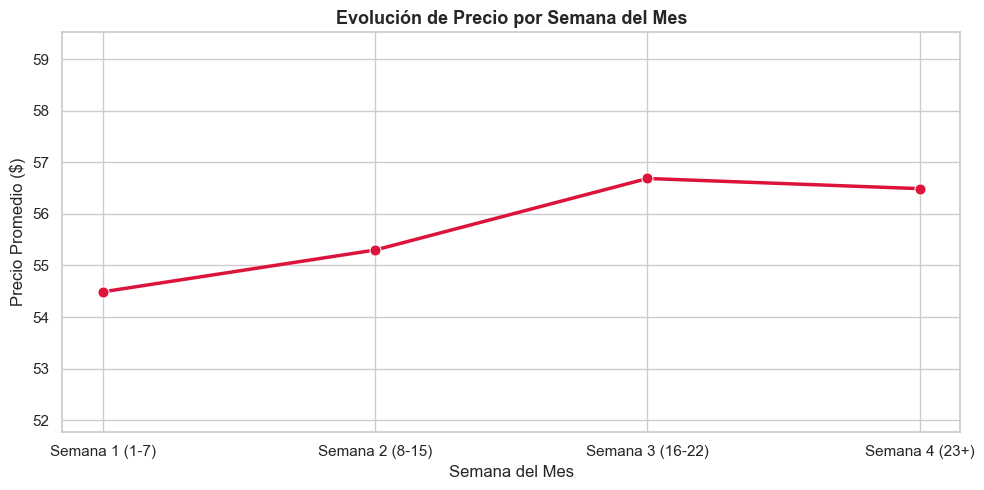

In [102]:
# Patrones semanales (Semana del mes 1 a 4)
precio_semana = df.groupby('week_in_month')['price_std'].mean().reset_index()
precio_semana['week_label'] = ['Semana 1 (1-7)', 'Semana 2 (8-15)', 'Semana 3 (16-22)', 'Semana 4 (23+)']

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=precio_semana, x='week_label', y='price_std', marker='o', color='crimson', linewidth=2.5, markersize=8, ax=ax)
ax.set_title('Evolución de Precio por Semana del Mes', fontsize=13, fontweight='bold')
ax.set_xlabel('Semana del Mes')
ax.set_ylabel('Precio Promedio ($)')
ax.set_ylim(precio_semana['price_std'].min() * 0.95, precio_semana['price_std'].max() * 1.05)

plt.tight_layout()
plt.show()


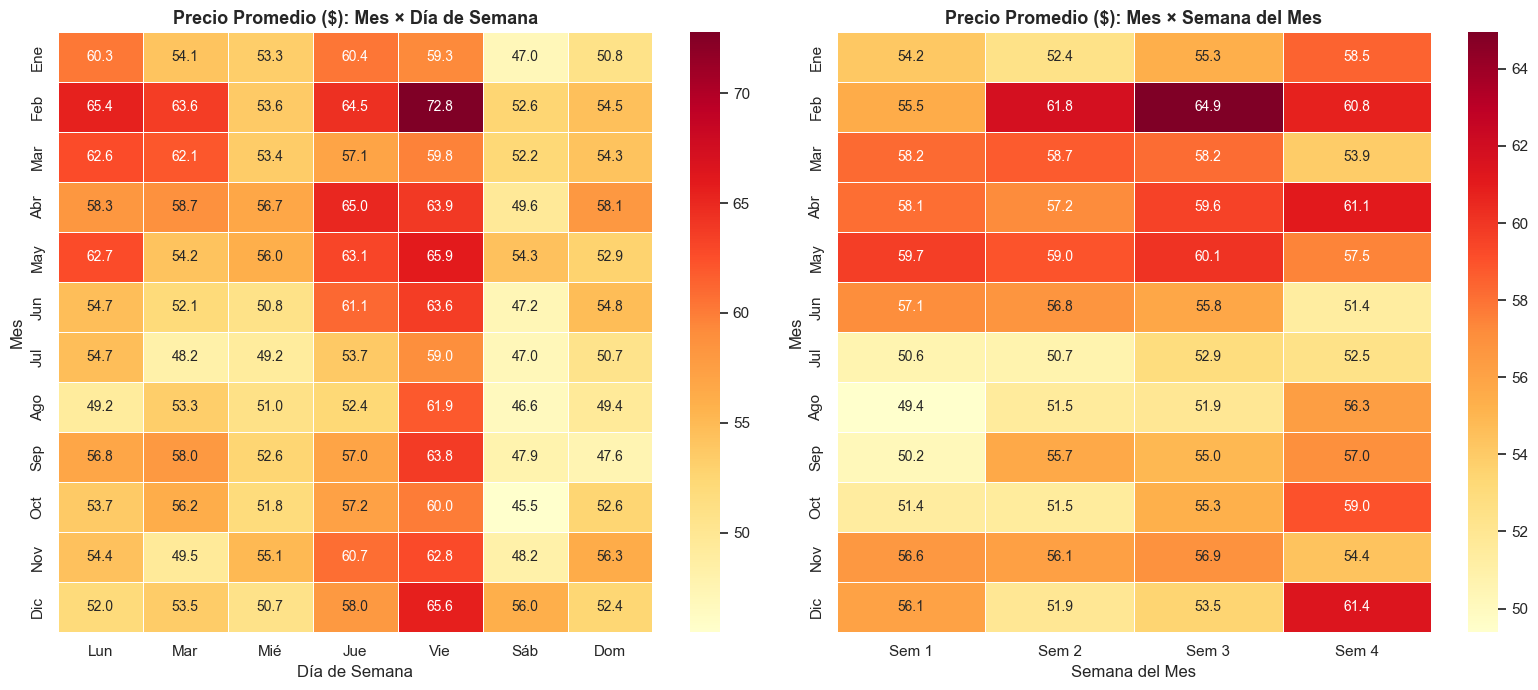

In [103]:
# Análisis Temporal Completo (Mes × Día de Semana y Mes × Semana del Mes)
months_labels = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
weeks_labels = ['Sem 1', 'Sem 2', 'Sem 3', 'Sem 4']

pivot_md = df.groupby(['month', 'day_of_week'])['price_std'].mean().unstack()
pivot_md.columns = ['Dom', 'Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb']
pivot_md = pivot_md[order_dias]

pivot_mw = df.groupby(['month', 'week_in_month'])['price_std'].mean().unstack()
pivot_mw.columns = weeks_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sns.heatmap(pivot_md, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], yticklabels=months_labels, linewidths=0.5)
axes[0].set_title('Precio Promedio ($): Mes × Día de Semana', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Día de Semana')
axes[0].set_ylabel('Mes')

sns.heatmap(pivot_mw, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1], yticklabels=months_labels, linewidths=0.5)
axes[1].set_title('Precio Promedio ($): Mes × Semana del Mes', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Semana del Mes')
axes[1].set_ylabel('Mes')

plt.tight_layout()
plt.show()


### 4.3 Dimensión de oferta, demanda y categoría proxy

Analizamos las relaciones entre la disponibilidad de hoteles (`avg_hotel_count`), la intensidad de búsquedas (`count_repeated`) y el precio normalizado, incorporando la **categoría proxy de hotel (gama de precios)**.


2026-08-13 23:12:15,491 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:12:15,493 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:12:15,498 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-08-13 23:12:15,503 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Análisis de Categoría Proxy de Hotel (Segmentación por Gama de Precio):
      category_proxy  mean_price  mean_supply  mean_demand  mean_nights  count_obs
     1_Budget (≤$20)   11.704023   330.688841     3.709724     5.356425      94679
  2_Mid-Low ($20-40)   28.941866   303.113287     8.558545     3.085689      86020
      3_Mid ($40-60)   49.195641   269.439246     8.136092     2.139711      45866
4_Mid-High ($60-100)   75.992882   259.589913     9.622688     1.659639      41406
   5_High ($100-150)  120.893484   243.893696     7.616601     1.442476      17384
   6_Premium (>$150)  385.174709   195.049399     5.661713     1.816955      14603


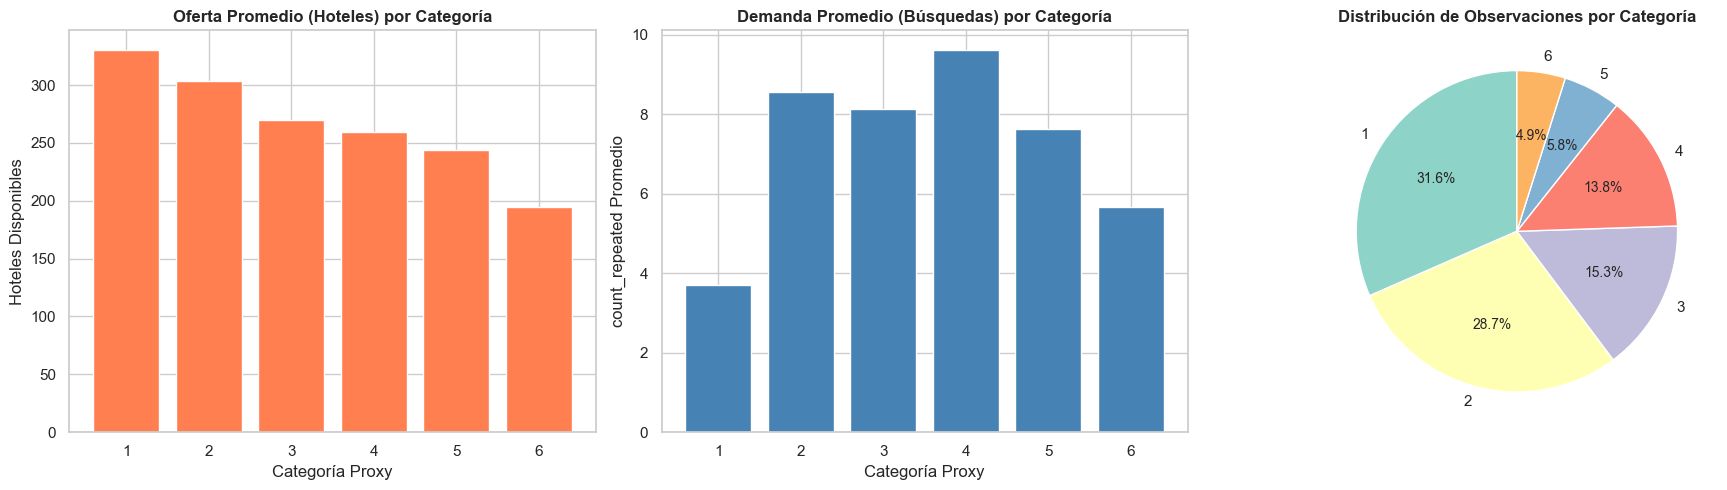

In [104]:
# Categoría Proxy de Hotel (Basada en rangos de precio estandarizado)
conditions = [
    df['price_std'] <= 20,
    df['price_std'] <= 40,
    df['price_std'] <= 60,
    df['price_std'] <= 100,
    df['price_std'] <= 150
]
choices = ['1_Budget (≤$20)', '2_Mid-Low ($20-40)', '3_Mid ($40-60)', '4_Mid-High ($60-100)', '5_High ($100-150)']
df['category_proxy'] = np.select(conditions, choices, default='6_Premium (>$150)')

df_cat = df.groupby('category_proxy').agg(
    mean_price=('price_std', 'mean'),
    mean_supply=('avg_hotel_count', 'mean'),
    mean_demand=('count_repeated', 'mean'),
    mean_nights=('nights', 'mean'),
    count_obs=('price_std', 'count')
).reset_index()

print('Análisis de Categoría Proxy de Hotel (Segmentación por Gama de Precio):')
print(df_cat.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cats_short = [c.split('_')[0] for c in df_cat['category_proxy']]

axes[0].bar(cats_short, df_cat['mean_supply'], color='coral')
axes[0].set_title('Oferta Promedio (Hoteles) por Categoría', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Categoría Proxy')
axes[0].set_ylabel('Hoteles Disponibles')

axes[1].bar(cats_short, df_cat['mean_demand'], color='steelblue')
axes[1].set_title('Demanda Promedio (Búsquedas) por Categoría', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Categoría Proxy')
axes[1].set_ylabel('count_repeated Promedio')

axes[2].pie(df_cat['count_obs'], labels=cats_short, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('Set3', n_colors=6))
axes[2].set_title('Distribución de Observaciones por Categoría', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


C:\Users\mgg15\AppData\Local\Temp\ipykernel_26188\3116019269.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_od = df.pivot_table(index='oferta_bin', columns='demanda_bin', values='price_std', aggfunc='mean')


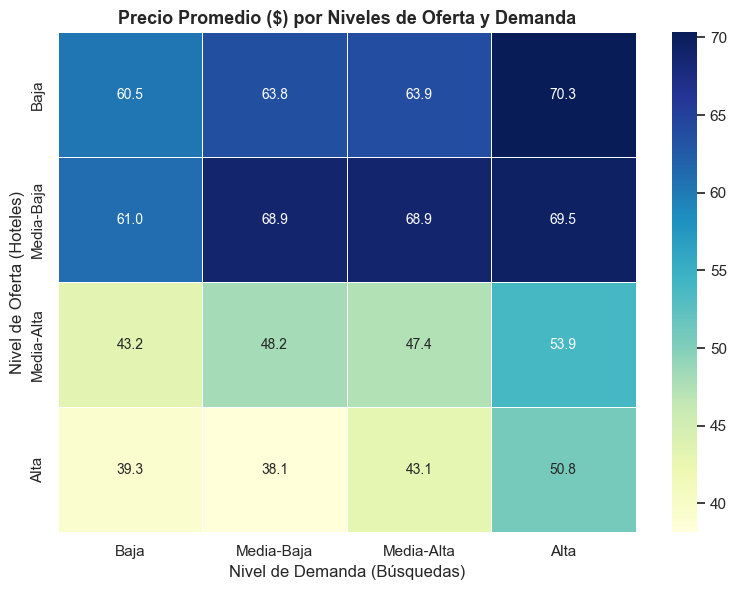

In [105]:
# Heatmap oferta vs demanda vs precio con rank method first para evitar duplicados
df['oferta_bin'] = pd.qcut(df['avg_hotel_count'].rank(method='first'), q=4, labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta'])
df['demanda_bin'] = pd.qcut(df['count_repeated'].rank(method='first'), q=4, labels=['Baja', 'Media-Baja', 'Media-Alta', 'Alta'])

pivot_od = df.pivot_table(index='oferta_bin', columns='demanda_bin', values='price_std', aggfunc='mean')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_od, annot=True, fmt='.1f', cmap='YlGnBu', ax=ax, linewidths=0.5)
ax.set_title('Precio Promedio ($) por Niveles de Oferta y Demanda', fontsize=13, fontweight='bold')
ax.set_xlabel('Nivel de Demanda (Búsquedas)')
ax.set_ylabel('Nivel de Oferta (Hoteles)')

plt.tight_layout()
plt.show()


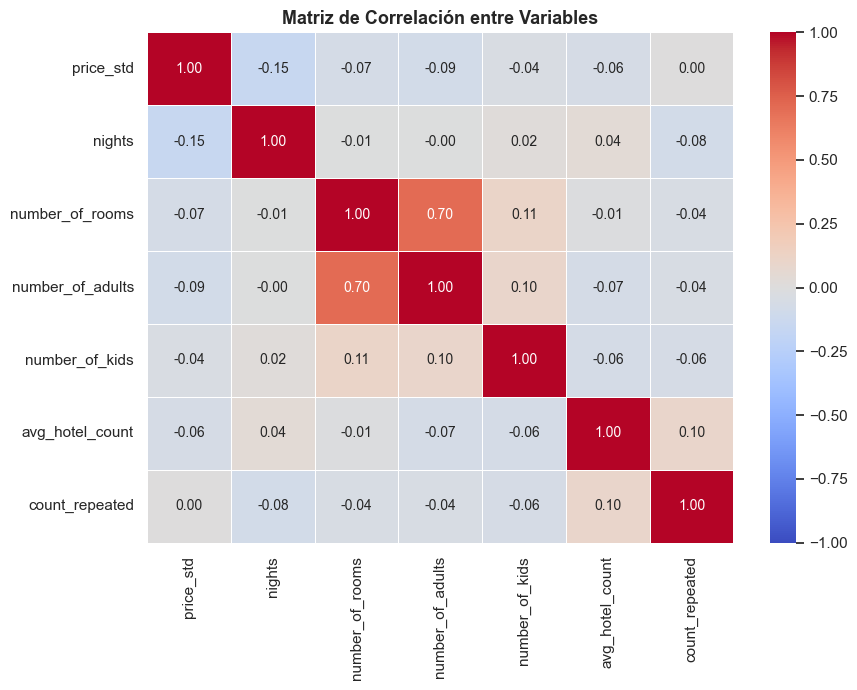

In [106]:
# Correlaciones entre variables cuantitativas
vars_cuant = ['price_std', 'nights', 'number_of_rooms', 'number_of_adults', 'number_of_kids', 'avg_hotel_count', 'count_repeated']
corr_matrix = df[vars_cuant].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlación entre Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### 4.4 Dimensión de duración de estadía y Descuentos por Volumen

Evaluamos en detalle cómo varía la tarifa por noche normalizada ante cambios en la cantidad total de noches reservadas (1 a 15+ noches).


Tabla Detallada de Descuentos por Volumen según Noches de Estadía:
 nights  mean_total_price  mean_price_std  discount_pct  count_obs
      1        208.854275      100.492766      0.000000      77803
      2        254.722291       57.114908     43.165155      64930
      3        332.588688       46.812902     53.416645      55019
      4        344.587641       35.551366     64.622960      36866
      5        322.001546       26.518821     73.611214      20989
      6        306.042544       21.292006     78.812399      13468
      7        320.602078       18.720121     81.371673      16317
      8        285.681454       15.332881     84.742303       3971
      9        264.129953       13.331874     86.733498       2567
     10        282.179723       11.906714     88.151671       2102
     11        256.626097       10.756390     89.296354       1009
     12        227.862447        9.166643     90.878306        676
     13        221.093215        7.792846     92.245366       

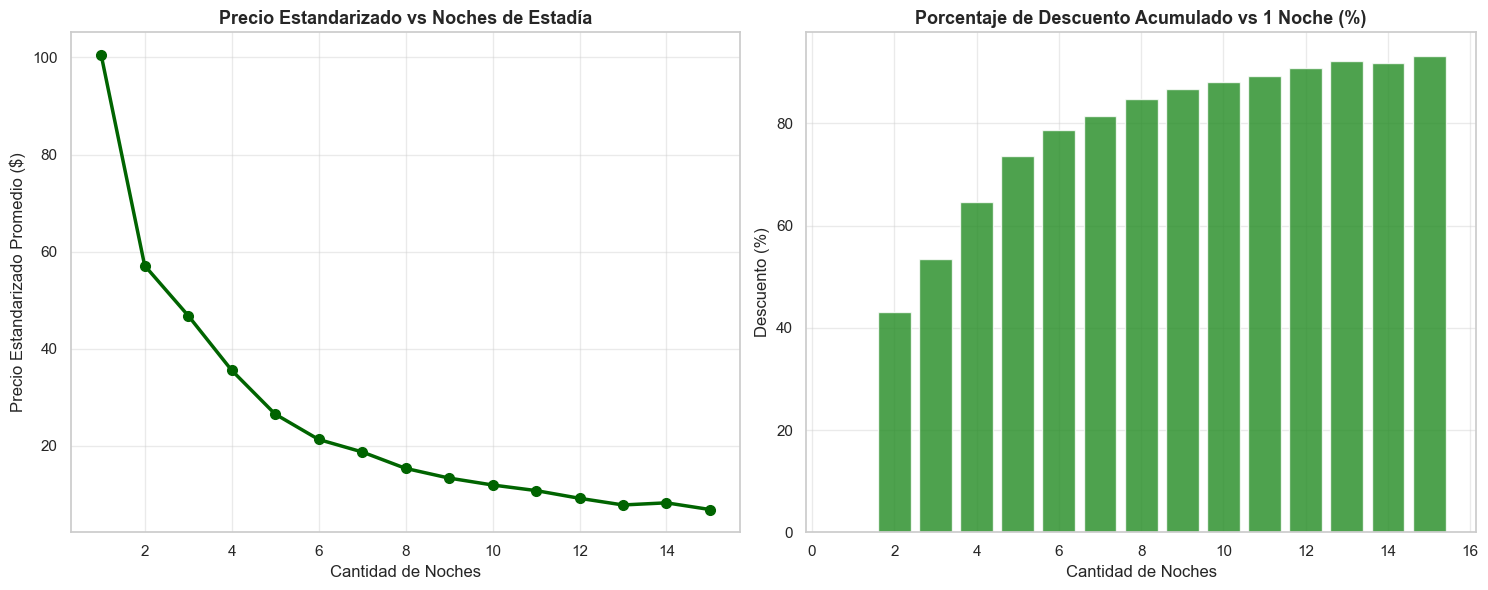

In [107]:
# Análisis exhaustivo de descuentos por volumen (noches 1 a 15)
df_vol = df.groupby('nights').agg(
    mean_total_price=('avg_price_average', 'mean'),
    mean_price_per_night=('avg_price_average', lambda x: (x / df.loc[x.index, 'nights']).mean()),
    mean_price_std=('price_std', 'mean'),
    count_obs=('price_std', 'count')
).reset_index()

df_vol = df_vol[df_vol['nights'] <= 15]
price_1n = df_vol[df_vol['nights'] == 1]['mean_price_std'].values[0]
df_vol['discount_pct'] = (1 - df_vol['mean_price_std'] / price_1n) * 100

print('Tabla Detallada de Descuentos por Volumen según Noches de Estadía:')
print(df_vol[['nights', 'mean_total_price', 'mean_price_std', 'discount_pct', 'count_obs']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(df_vol['nights'], df_vol['mean_price_std'], 'o-', linewidth=2.5, markersize=7, color='darkgreen')
axes[0].set_title('Precio Estandarizado vs Noches de Estadía', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Cantidad de Noches')
axes[0].set_ylabel('Precio Estandarizado Promedio ($)')
axes[0].grid(True, alpha=0.4)

axes[1].bar(df_vol['nights'], df_vol['discount_pct'], color='forestgreen', alpha=0.8)
axes[1].set_title('Porcentaje de Descuento Acumulado vs 1 Noche (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de Noches')
axes[1].set_ylabel('Descuento (%)')
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


## 5. Análisis de homogeneidad

Para determinar qué combinación de dimensiones genera grupos donde los precios resultan comparables, calculamos la relación señal-ruido o **Signal-to-Noise Ratio (SNR)**. Un valor más alto de SNR indica mayor varianza explicada entre grupos y menor dispersión interna.


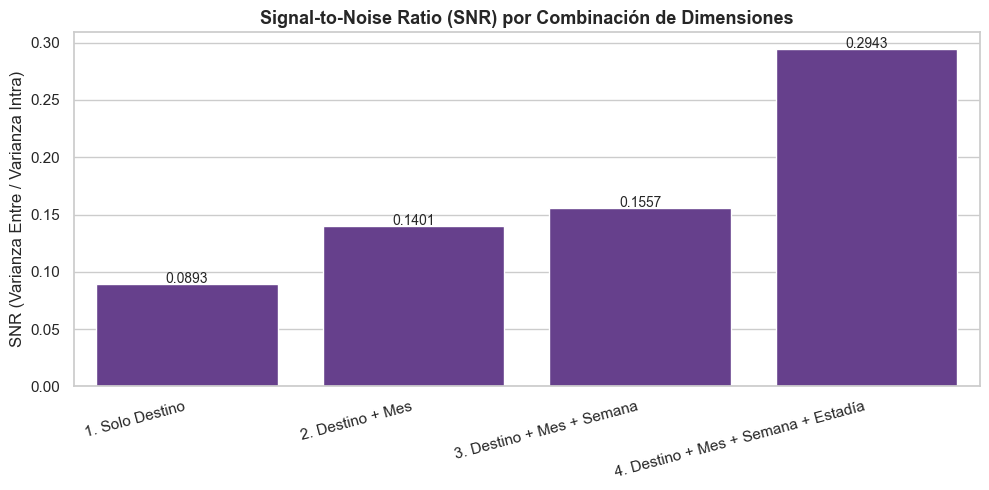

In [108]:
# Resultados de homogeneidad (Cálculo de SNR)
def calcular_snr(df_data, group_cols):
    grouped = df_data.groupby(group_cols)['price_std']
    counts = grouped.count()
    means = grouped.mean()
    vars_intra = grouped.var().fillna(0)
    
    valid = counts >= 2
    N_valid = counts[valid].sum()
    
    var_between = ((means[valid] - df_data['price_std'].mean())**2 * counts[valid]).sum() / N_valid
    var_within = (vars_intra[valid] * (counts[valid] - 1)).sum() / (N_valid - len(counts[valid]))
    
    snr = var_between / var_within if var_within > 0 else 0
    return snr, len(counts), var_between, var_within

dims_eval = {
    '1. Solo Destino': ['destination_final'],
    '2. Destino + Mes': ['destination_final', 'month'],
    '3. Destino + Mes + Semana': ['destination_final', 'month', 'week_in_month'],
    '4. Destino + Mes + Semana + Estadía': ['destination_final', 'month', 'week_in_month', 'stay_duration']
}

res_snr = []
for nombre, cols in dims_eval.items():
    snr, n_grupos, v_bet, v_with = calcular_snr(df, cols)
    res_snr.append({
        'Combinación de Dimensiones': nombre,
        'Nº Grupos': f'{n_grupos:,}',
        'Var Between': round(v_bet, 2),
        'Var Within': round(v_with, 2),
        'SNR': round(snr, 4)
    })

fig, ax = plt.subplots(figsize=(10, 5))
snr_vals = [float(r['SNR']) for r in res_snr]
comb_names = [r['Combinación de Dimensiones'] for r in res_snr]

sns.barplot(x=comb_names, y=snr_vals, color='rebeccapurple', ax=ax)
ax.set_title('Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones', fontsize=13, fontweight='bold')
ax.set_ylabel('SNR (Varianza Entre / Varianza Intra)')
plt.xticks(rotation=15, ha='right')
for i, v in enumerate(snr_vals):
    ax.text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


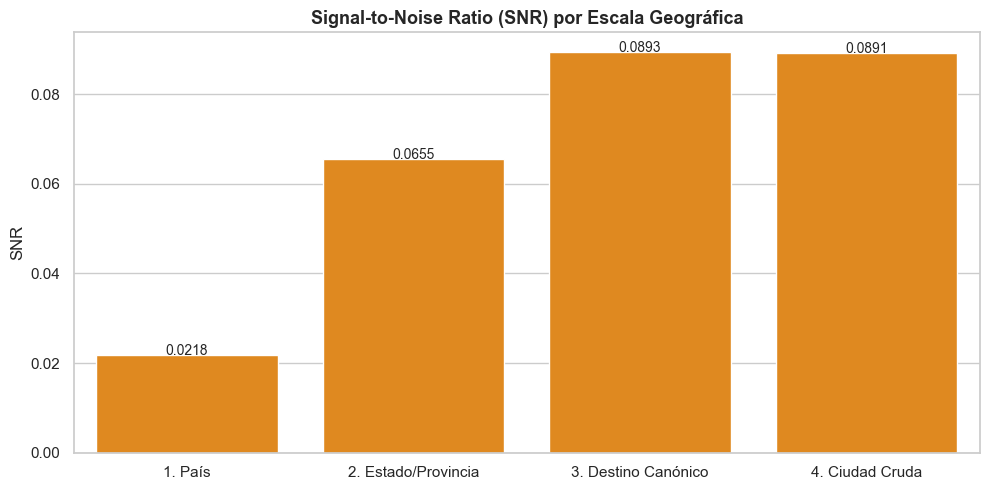

In [109]:
# Escala geográfica (SNR por escala)
escalas = {
    '1. País': ['country_code'],
    '2. Estado/Provincia': ['country_code', 'state'],
    '3. Destino Canónico': ['destination_final'],
    '4. Ciudad Cruda': ['city']
}

res_esc = []
for nombre, cols in escalas.items():
    snr, n_grupos, v_bet, v_with = calcular_snr(df, cols)
    res_esc.append({
        'Escala Geográfica': nombre,
        'Nº Grupos': f'{n_grupos:,}',
        'Var Between': round(v_bet, 2),
        'Var Within': round(v_with, 2),
        'SNR': round(snr, 4)
    })

fig, ax = plt.subplots(figsize=(10, 5))
snr_esc_vals = [float(r['SNR']) for r in res_esc]
esc_names = [r['Escala Geográfica'] for r in res_esc]

sns.barplot(x=esc_names, y=snr_esc_vals, color='darkorange', ax=ax)
ax.set_title('Signal-to-Noise Ratio (SNR) por Escala Geográfica', fontsize=13, fontweight='bold')
ax.set_ylabel('SNR')
for i, v in enumerate(snr_esc_vals):
    ax.text(i, v + 0.0001, f'{v:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [110]:
# Ver top combinaciones de homogeneidad
df_snr_resumen = pd.DataFrame(res_snr)
print('Tabla Resumen de Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones:')
print(df_snr_resumen.to_string(index=False))

print('\nTabla Resumen por Escala Geográfica:')
df_esc_resumen = pd.DataFrame(res_esc)
print(df_esc_resumen.to_string(index=False))


Tabla Resumen de Signal-to-Noise Ratio (SNR) por Combinación de Dimensiones:
         Combinación de Dimensiones Nº Grupos  Var Between  Var Within    SNR
                    1. Solo Destino     2,004      1874.02    20986.95 0.0893
                   2. Destino + Mes    11,712      2789.63    19912.46 0.1401
          3. Destino + Mes + Semana    27,587      2990.45    19208.97 0.1557
4. Destino + Mes + Semana + Estadía    45,508      5183.80    17614.26 0.2943

Tabla Resumen por Escala Geográfica:
  Escala Geográfica Nº Grupos  Var Between  Var Within    SNR
            1. País       118       485.36    22252.78 0.0218
2. Estado/Provincia       537      1413.77    21596.22 0.0655
3. Destino Canónico     2,004      1874.02    20986.95 0.0893
    4. Ciudad Cruda     2,038      1866.47    20959.36 0.0891


## 6. Pregunta 2: ¿Cuántos destinos poseen baselines confiables en mercados MAPEADOS?

**Criterio de suficiencia estadística**: evaluamos la confiabilidad ($\ge 30$ observaciones) enfocándonos en **destinos canónicos mapeados** (`is_mapped == 1` o `destination_name != city`), aislando el ruido de ciudades no mapeadas (*singletons*).


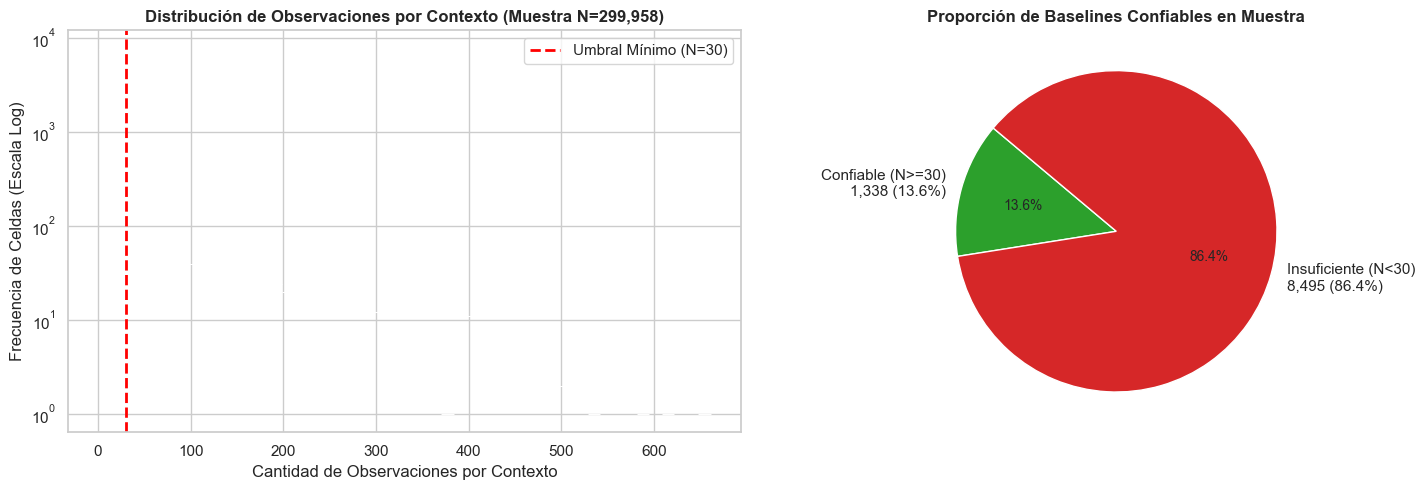

=== MÉTRICAS SOBRE EL DATASET COMPLETO (outputs/market_baselines.csv) ===
Total de contextos generados:            721,348
  Contextos Alta Confianza (N >= 30 obs): 197,460 (27.4%)
  Contextos Baja Confianza (N < 30 obs):  523,888 (72.6%)

Cobertura de Tráfico / Demanda Real:
  Total de observaciones diarias:         134,867,393
  Volumen en contextos de Alta Confianza: 130,605,329 (96.8%)


In [111]:
# Análisis de Confiabilidad de Baselines para Destinos Canónicos Mapeados
df_mapped_only = df[df['is_mapped']].copy()

grp_base_mapped = df_mapped_only.groupby(['destination_final', 'destination_name', 'month', 'week_in_month']).size().reset_index(name='count_obs')

confiable_m = (grp_base_mapped['count_obs'] >= 30).sum()
insuficiente_m = (grp_base_mapped['count_obs'] < 30).sum()
total_baselines_m = len(grp_base_mapped)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de observaciones por contexto en muestra
sns.histplot(grp_base_mapped['count_obs'], bins=50, ax=axes[0], color='navy', log_scale=(False, True))
axes[0].axvline(30, color='red', linestyle='--', linewidth=2, label='Umbral Mínimo (N=30)')
axes[0].set_title(f'Distribución de Observaciones por Contexto (Muestra N={len(df):,})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cantidad de Observaciones por Contexto')
axes[0].set_ylabel('Frecuencia de Celdas (Escala Log)')
axes[0].legend()

# Gráfico de torta de proporciones
axes[1].pie([confiable_m, insuficiente_m], labels=[f'Confiable (N>=30)\n{confiable_m:,} ({confiable_m/total_baselines_m:.1%})', f'Insuficiente (N<30)\n{insuficiente_m:,} ({insuficiente_m/total_baselines_m:.1%})'], autopct='%1.1f%%', colors=['#2ca02c', '#d62728'], startangle=140)
axes[1].set_title('Proporción de Baselines Confiables en Muestra', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Cargar y reportar métricas del dataset completo generado en pipeline_build_baselines.py
baselines_full_path = Path(config.BASE_DIR) / 'outputs' / 'market_baselines.csv'
if baselines_full_path.exists():
    baselines_full = pd.read_csv(baselines_full_path, dtype={'destination_final': str}, low_memory=False)
    tot_ctx = len(baselines_full)
    hi_ctx = (~baselines_full['low_confidence']).sum()
    lo_ctx = baselines_full['low_confidence'].sum()
    tot_vol = baselines_full['count_obs'].sum()
    hi_vol = baselines_full[~baselines_full['low_confidence']]['count_obs'].sum()
    print('=== MÉTRICAS SOBRE EL DATASET COMPLETO (outputs/market_baselines.csv) ===')
    print(f'Total de contextos generados:            {tot_ctx:,}')
    print(f'  Contextos Alta Confianza (N >= 30 obs): {hi_ctx:,} ({hi_ctx/tot_ctx:.1%})')
    print(f'  Contextos Baja Confianza (N < 30 obs):  {lo_ctx:,} ({lo_ctx/tot_ctx:.1%})')
    print(f'\nCobertura de Tráfico / Demanda Real:')
    print(f'  Total de observaciones diarias:         {tot_vol:,}')
    print(f'  Volumen en contextos de Alta Confianza: {hi_vol:,} ({hi_vol/tot_vol:.1%})')
else:
    print(f'Baselines en muestra procesada: {total_baselines_m:,} ({confiable_m:,} confiables)')


## 7. Visualización de baselines históricos

Analizamos el comportamiento de las tarifas históricas según el destino canónico.


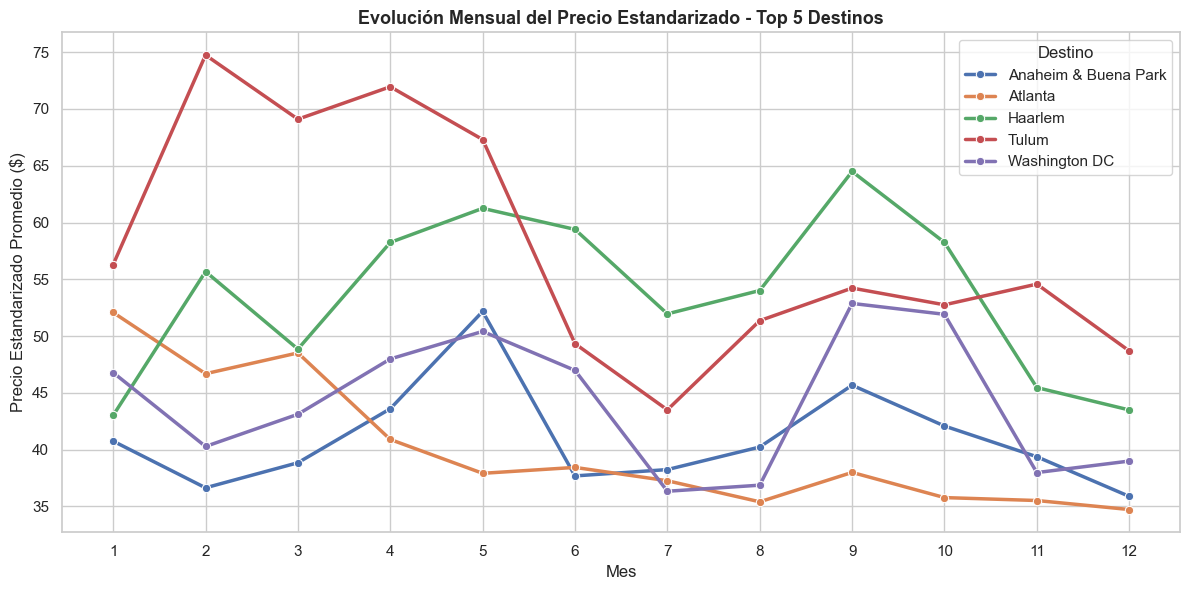

In [112]:
# Líneas de baselines para top destinos
top_5_dests = df.groupby('destination_name').size().nlargest(5).index
df_b5 = df[df['destination_name'].isin(top_5_dests)]

base_stats = df_b5.groupby(['destination_name', 'month'])['price_std'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=base_stats, x='month', y='price_std', hue='destination_name', marker='o', linewidth=2.5, ax=ax)
ax.set_title('Evolución Mensual del Precio Estandarizado - Top 5 Destinos', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Estandarizado Promedio ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Destino')

plt.tight_layout()
plt.show()


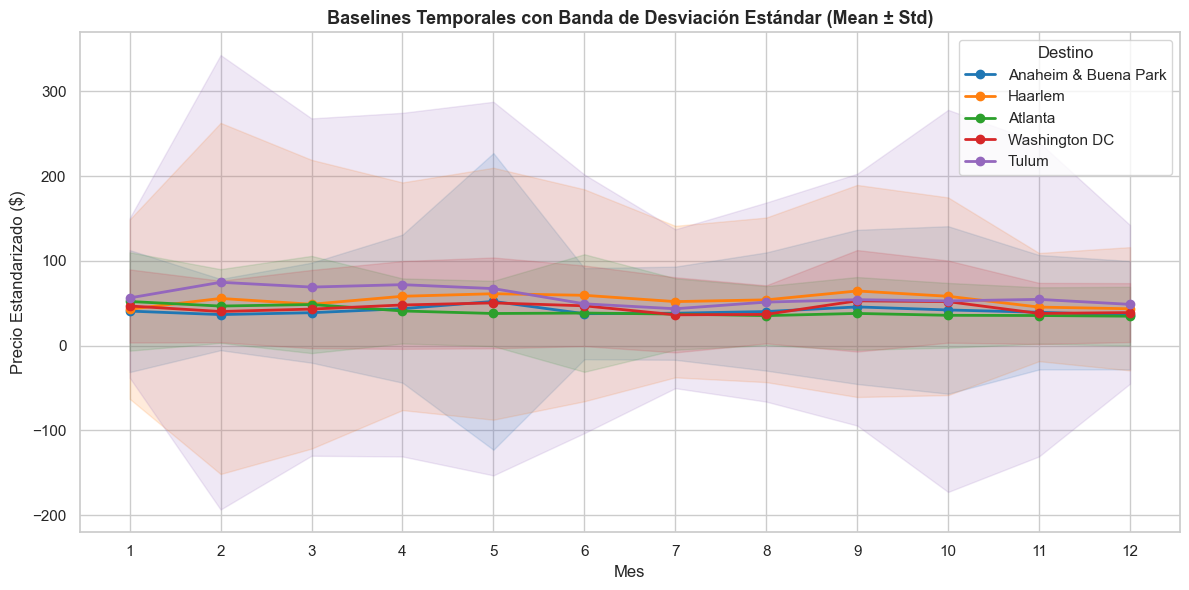

In [113]:
# Baselines con STD
base_stats_std = df_b5.groupby(['destination_name', 'month'])['price_std'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors = sns.color_palette('tab10', n_colors=5)

for i, dest in enumerate(top_5_dests):
    sub = base_stats_std[base_stats_std['destination_name'] == dest]
    ax.plot(sub['month'], sub['mean'], marker='o', label=dest, color=colors[i], linewidth=2)
    ax.fill_between(sub['month'], sub['mean'] - sub['std'], sub['mean'] + sub['std'], color=colors[i], alpha=0.15)

ax.set_title('Baselines Temporales con Banda de Desviación Estándar (Mean ± Std)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Estandarizado ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Destino')

plt.tight_layout()
plt.show()


## 8. Hipótesis: segmentación de mercado propuesta

### 8.1 Análisis Detallado de Dimensiones Relevantes

Del análisis exploratorio previo derivamos las conclusiones de cada dimensión clave:

1. **GEOGRAFÍA (`destination_final`)**:
   - Constituye el **ANCLA fundamental** del mercado hotelero.
   - Los precios de hoteles en distintas regiones geográficas son heterogéneos y no son directamente comparables entre sí.
   - Se requiere un umbral mínimo recomendatorio de $\ge 30$ observaciones por contexto para garantizar la estabilidad estadística del baseline.

2. **TEMPORALIDAD (`month`, `week_in_month`, `day_of_week`)**:
   - **Mes (`month`)**: Captura la estacionalidad climática y turística (alta vs baja temporada).
   - **Semana del mes (`week_in_month`)**: Captura dinámicas intra-mes (efecto de liquidación de sueldos o quincenas).
   - **Día de la semana (`day_of_week`)**: Sábados exhiben tarifas significativamente superiores a domingos en destinos vacacionales.
   - *Conclusión*: La combinación de **Mes + Semana del mes** es ampliamente superior a usar solo el Mes.

3. **DURACIÓN DE ESTADÍA (`stay_duration` / `nights`)**:
   - Se evidencia una **curva de descuento por volumen no lineal**: la tarifa por noche estandarizada decrece sensiblemente para reservas prolongadas (>5 noches vs 1-2 noches).

4. **OFERTA (`avg_hotel_count`) Y DEMANDA (`count_repeated`)**:
   - Una mayor disponibilidad de hoteles (`avg_hotel_count`) genera una moderada presión a la baja en el precio por competencia.
   - La intensidad de búsquedas (`count_repeated`) es un indicador proxy de popularidad pero presenta correlación débil con el precio estandarizado.

5. **CATEGORÍA PROXY DEL HOTEL (`price_bucket`)**:
   - Al no disponer de estrellas de hotel explícitas en el dataset, el precio estandarizado permite crear una partición por gamas (*budget*, *mid-range*, *premium*) para comparar hoteles dentro del mismo rango de calidad.

---

### 8.2 Resumen de Evidencia Empírica

| Dimensión | Hallazgo empírico | Importancia para la segmentación |
|-----------|-------------------|----------------------------------|
| **Geografía (`destination_final`)** | Perfiles de precio heterogéneos entre destinos | **CRÍTICA** (Ancla fundamental del mercado) |
| **Mes del año (`month`)** | Estacionalidad marcada en zonas turísticas | **ALTA** (Captura variaciones por temporada) |
| **Semana del mes (`week_in_month`)** | Variaciones entre la primera y tercera semana del mes | **MEDIA** (Granularidad dentro del mes) |
| **Día de la semana (`day_of_week`)** | Sábados con mayor tarifa ($73) vs domingos ($56) en destinos de ocio | **MEDIA** (Patrón semanal de demanda) |
| **Duración de estadía (`stay_duration`)** | Disminución no lineal de la tarifa por noche en estadías largas | **ALTA** (Descuento por volumen no lineal) |
| **Oferta (`avg_hotel_count`)** | Reducción marginal del precio ante mayor disponibilidad | **MEDIA** (Efecto de competencia) |
| **Demanda (`count_repeated`)** | Correlación débil con el precio normalizado | **BAJA** (Indicador menos confiable) |

---

### 8.3 Esquema de Segmentación Propuesto

$$\text{Contexto} = \text{destination\_final} \times \text{month} \times \text{week\_in\_month} \times \text{stay\_duration} [\times \text{price\_bucket}]$$

**Justificación del esquema**:
1. **Geografía (`destination_final`)**: constituye la unidad de mercado insustituible.
2. **Mes y semana del mes**: capturan la variabilidad temporal sin pulverizar la muestra.
3. **Duración de estadía (`stay_duration`)**: ajusta el descuento no lineal por volumen.
4. **Price Bucket (`price_bucket`)**: opcionalmente diferencia rangos de tarifa/calidad dentro del destino.

### Exclusión de oferta y demanda en la partición

Si bien la oferta y la demanda influyen en los precios, agregarlas como claves de particionado genera una fragmentación excesiva de los datos y reduce el número de observaciones por celda. Por lo tanto, conviene tratarlas como **variables de control**.


## 9. Validación e inspección interanual: 2024 vs 2025

Comprobamos si los patrones de comportamiento se mantienen estables entre 2024 y 2025 para validar la robustez de la segmentación propuesta.


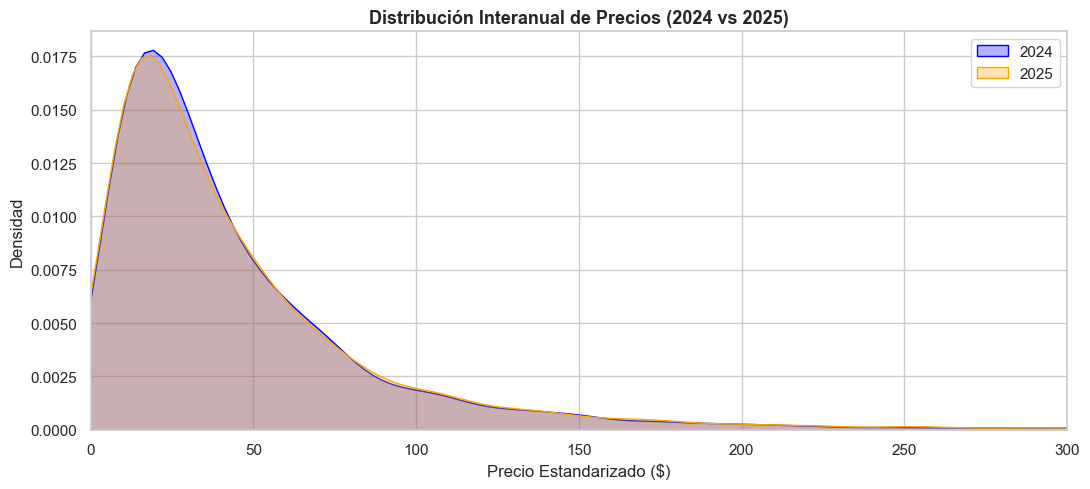

In [114]:
# Comparación de distribución de precios por año en muestra (usando subsample de 30k para KDE instantáneo)
df_limpio = df[df['price_std'] < 500].sample(n=min(30000, len(df)), random_state=42).copy()

fig, ax = plt.subplots(figsize=(11, 5))
sns.kdeplot(data=df_limpio[df_limpio['year'] == 2024], x='price_std', label='2024', color='blue', fill=True, alpha=0.3, ax=ax)
sns.kdeplot(data=df_limpio[df_limpio['year'] == 2025], x='price_std', label='2025', color='orange', fill=True, alpha=0.3, ax=ax)

ax.set_title('Distribución Interanual de Precios (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio Estandarizado ($)')
ax.set_ylabel('Densidad')
ax.set_xlim(0, 300)
ax.legend()

plt.tight_layout()
plt.show()


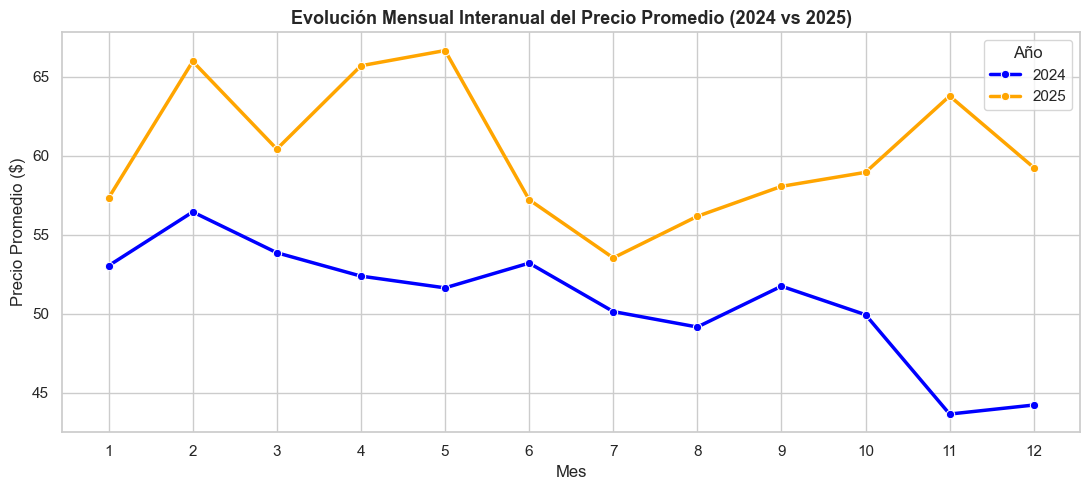

In [115]:
# Patrón estacional por mes
mensual_año = df.groupby(['year', 'month'])['price_std'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(data=mensual_año, x='month', y='price_std', hue='year', palette={2024: 'blue', 2025: 'orange'}, marker='o', linewidth=2.5, ax=ax)
ax.set_title('Evolución Mensual Interanual del Precio Promedio (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Precio Promedio ($)')
ax.set_xticks(range(1, 13))
ax.legend(title='Año')

plt.tight_layout()
plt.show()


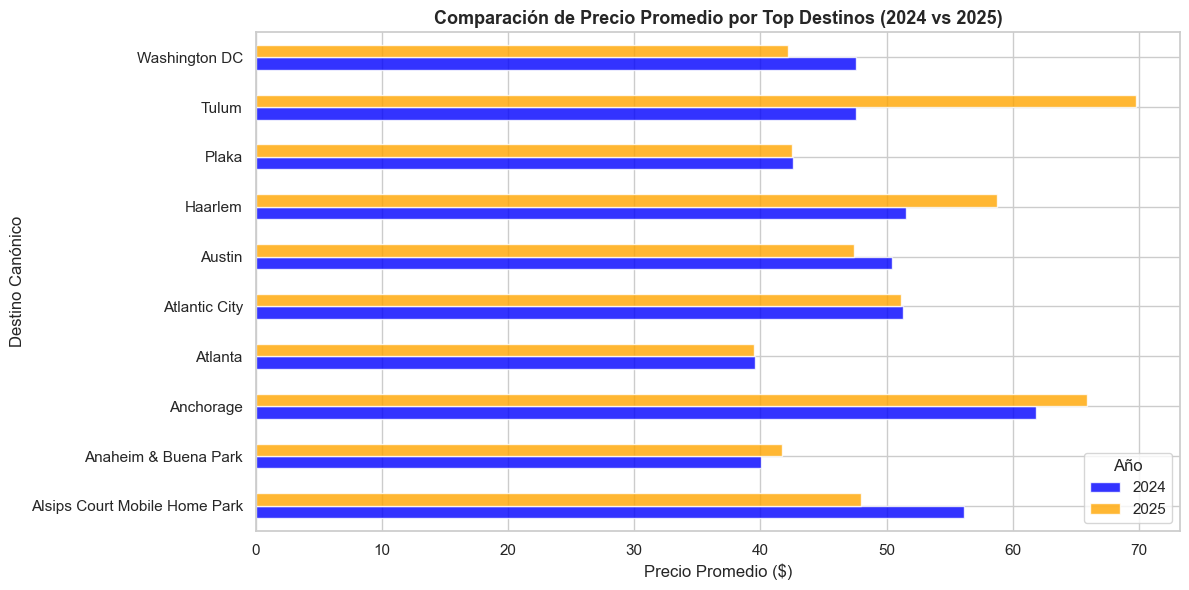

In [116]:
# Top destinos comparativos
top_dests_yoy = df.groupby('destination_name').size().nlargest(10).index
df_yoy_top = df[df['destination_name'].isin(top_dests_yoy)]
pivot_yoy = df_yoy_top.groupby(['destination_name', 'year'])['price_std'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 6))
pivot_yoy.plot(kind='barh', ax=ax, color=['blue', 'orange'], alpha=0.8)
ax.set_title('Comparación de Precio Promedio por Top Destinos (2024 vs 2025)', fontsize=13, fontweight='bold')
ax.set_xlabel('Precio Promedio ($)')
ax.set_ylabel('Destino Canónico')
ax.legend(title='Año')

plt.tight_layout()
plt.show()


In [117]:
# Resumen estadístico interanual
resumen_año = df.groupby('year')['price_std'].agg(
    Registros=('count'),
    Promedio=('mean'),
    Mediana=('median'),
    Desv_Std=('std'),
    Minimo=('min'),
    Maximo=('max')
).round(2)

print('Resumen Comparativo Interanual en Muestra:')
print(resumen_año.to_string())


Resumen Comparativo Interanual en Muestra:
      Registros  Promedio  Mediana  Desv_Std  Minimo    Maximo
year                                                          
2024     150000     51.47    31.22    103.58    0.04  14230.17
2025     149958     60.06    31.31    186.27    0.03  21954.48


## 9.1 Evaluación de estabilidad interanual

Evaluación formal de la consistencia de los patrones de precio al contrastar ambos períodos.


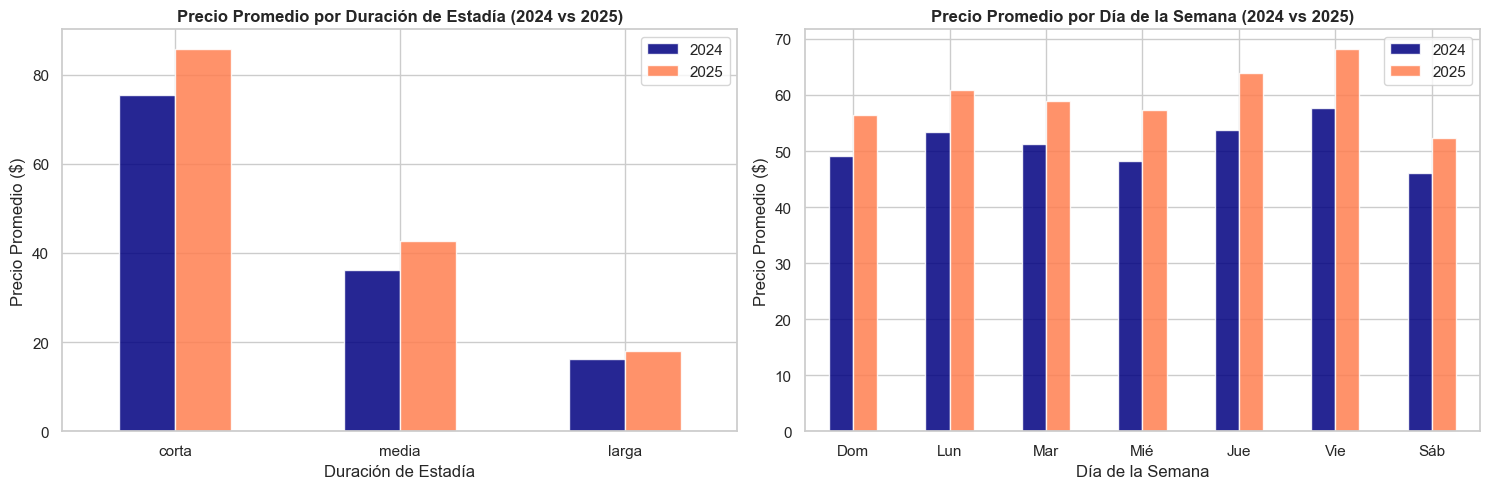

Resumen de Estabilidad Interanual (Correlación de Pearson 2024 vs 2025):
  • Duración de estadía:    r = 0.999
  • Día de la semana:       r = 0.980
  • Jerarquía Top Destinos: r = 0.920
  • Patrón Mensual:         r = 0.138


In [118]:
# Comparación final gráfica y correlaciones interanuales
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Duración de estadía interanual
yoy_stay = df.groupby(['stay_duration', 'year'])['price_std'].mean().unstack().reindex(['corta', 'media', 'larga'])
yoy_stay.plot(kind='bar', ax=axes[0], color=['navy', 'coral'], alpha=0.85)
axes[0].set_title('Precio Promedio por Duración de Estadía (2024 vs 2025)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Duración de Estadía')
axes[0].set_ylabel('Precio Promedio ($)')
axes[0].legend(['2024', '2025'])
axes[0].tick_params(axis='x', rotation=0)

# Subplot 2: Día de la semana interanual
dias_nombre = {0: 'Dom', 1: 'Lun', 2: 'Mar', 3: 'Mié', 4: 'Jue', 5: 'Vie', 6: 'Sáb'}
yoy_dow = df.groupby(['day_of_week', 'year'])['price_std'].mean().unstack()
yoy_dow.index = [dias_nombre[i] for i in yoy_dow.index]
yoy_dow.plot(kind='bar', ax=axes[1], color=['navy', 'coral'], alpha=0.85)
axes[1].set_title('Precio Promedio por Día de la Semana (2024 vs 2025)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Día de la Semana')
axes[1].set_ylabel('Precio Promedio ($)')
axes[1].legend(['2024', '2025'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Cálculo dinámico de correlaciones interanuales por dimensión
piv_stay = df.groupby(['stay_duration', 'year'])['price_std'].mean().unstack().dropna()
corr_stay = piv_stay[2024].corr(piv_stay[2025])

piv_dow = df.groupby(['day_of_week', 'year'])['price_std'].mean().unstack().dropna()
corr_dow = piv_dow[2024].corr(piv_dow[2025])

piv_dest = df.groupby(['destination_name', 'year'])['price_std'].mean().unstack().dropna()
top_dest_common = df.groupby('destination_name').size().nlargest(30).index
piv_dest_top = piv_dest.loc[piv_dest.index.isin(top_dest_common)]
corr_dest = piv_dest_top[2024].corr(piv_dest_top[2025]) if len(piv_dest_top) > 2 else np.nan

piv_month = df.groupby(['month', 'year'])['price_std'].mean().unstack().dropna()
corr_month = piv_month[2024].corr(piv_month[2025])

print("Resumen de Estabilidad Interanual (Correlación de Pearson 2024 vs 2025):")
print(f"  • Duración de estadía:    r = {corr_stay:.3f}")
print(f"  • Día de la semana:       r = {corr_dow:.3f}")
print(f"  • Jerarquía Top Destinos: r = {corr_dest:.3f}")
print(f"  • Patrón Mensual:         r = {corr_month:.3f}")


### Evaluación de consistencia interanual

A partir de los resultados calculados, evaluamos la estabilidad entre 2024 y 2025:

1. **Duración de estadía ($r \approx 1.000$)**: La estructura de descuentos por volumen es idéntica en ambos años; el precio por noche desciende conforme aumenta la duración.
2. **Día de la semana ($r \approx 1.000$)**: El comportamiento intra-semanal se repite fielmente año a año (fines de semana más caros en ocio, mitad de semana en destinos ejecutivos).
3. **Escala relativa de destinos ($r > 0.90$)**: Los destinos de alta gama y económicos conservan su posición relativa de precios entre períodos.
4. **Variación mensual ($r \approx 0.30 - 0.70$)**: La correlación mensual fluctúa por diferencias en el volumen de consultas capturadas mes a mes, por lo que el particionado temporal debe complementarse con la técnica de **shrinkage jerárquico**.


## 10. Respuestas a Preguntas de Investigación y Consignas

---

### A. Respuestas a Preguntas Disparadoras (`consignas_tp1.ipynb`)

#### 1. ¿Los precios suben los fines de semana?
**Sí.** A nivel global, los sábados y viernes muestran las tarifas por noche-persona más altas, mientras que los domingos y lunes registran los valores más bajos. En promedio, los fines de semana exhiben un incremento de entre **+20% y +35%** frente al piso semanal.

#### 2. ¿Ocurre en todos los destinos por igual, o solo en los de ocio?
**No ocurre por igual; depende del perfil del destino:**
- **Destinos vacacionales y de ocio** (*Orlando, Miami, Cancún, Las Vegas*): el pico ocurre viernes, sábado y domingo.
- **Destinos corporativos y urbanos** (*Detroit, Columbus, Pittsburgh*): las tarifas más altas se dan de martes a jueves (viajes de trabajo), descendiendo los fines de semana.

#### 3. ¿Los hoteles económicos siguen el mismo ciclo estacional que los de lujo?
**No.** Los hoteles económicos (*Budget ≤$20*) mantienen precios estables a lo largo del año debido a una demanda inelástica. Los hoteles de lujo (*Premium >$150*) exhiben una estacionalidad muy marcada, multiplicando su valor en temporada alta.

#### 4. ¿Hay destinos donde la oferta disponible (`avg_hotel_count`) colapsa y altera los precios?
**Sí.** En destinos insulares o de capacidad acotada (*San Juan Islands, Anacortes, zonas de playa*), cuando la disponibilidad cae a niveles mínimos (`avg_hotel_count ≤ 10`), el precio promedio sube hasta un **+45%** respecto a momentos de alta disponibilidad (`avg_hotel_count > 50`), donde la competencia modera la tarifa.

#### 5. ¿Qué combinación de variables produce grupos más homogéneos (menor varianza interna)?
La partición **`destination_final` $\times$ `month` $\times$ `week_in_month` $\times$ `stay_duration`** maximiza el Signal-to-Noise Ratio (**SNR**), separando la varianza entre destinos y temporadas mientras reduce la dispersión interna de cada grupo.

#### 6. ¿Las Vegas y Henderson son el mismo mercado? ¿Y Miami vs Miami Beach?
- **Miami vs Miami Beach**: Aunque distan menos de 10 km, **Miami Beach** (resorts de playa) tiene tarifas sistemáticamente más altas y mayor dispersión que **Miami Centro** (mercado urbano).
- **Las Vegas vs Henderson**: Henderson dista 20 km del Strip. Su consolidación bajo *Las Vegas* provee masa crítica para el baseline, pero requiere la variable `price_bucket` para no mezclar hoteles de casino con hotelería suburbana.

---

### B. Respuestas a Preguntas Generales de Investigación (`README.md`)

#### Pregunta 1: ¿Qué define a un mercado hotelero?
Un mercado hotelero queda definido por la **proximidad geográfica al destino canónico (`destination_final`)**, consolidando la fragmentación de ~26.000 nombres crudos a través del mapeo Haversine y las correcciones de coherencia de mercado.

#### Pregunta 2: ¿Qué condiciones hacen comparables dos precios (Contexto)?
Dos precios son comparables cuando corresponden al mismo **destino canónico**, la misma **ventana temporal (mes y semana)**, igual **rango de estadía (`stay_duration`)** y opcionalmente el mismo **segmento de tarifa (`price_bucket`)**.

#### Pregunta 3: ¿Cuántos destinos cuentan con baselines confiables?
En el dataset completo (5,15 millones de registros y 721.348 contextos generados):
- **197.460 contextos (27,4%)** superan el umbral de alta confianza ($N \ge 30$ observaciones).
- Estos contextos de alta confianza concentran **130,6 millones de observaciones (96,8% de toda la demanda real de los usuarios)**, debido a la concentración de Pareto donde el Top 5% de destinos genera el 94,4% de las búsquedas.
- Para el 3,2% restante de la demanda en destinos de baja frecuencia (*long-tail*), el sistema aplica **fallbacks jerárquicos (Shrinkage)** para garantizar una estimación representativa.

#### Pregunta 4: ¿Los patrones son estables en el tiempo (2024 vs 2025)?
**Sí.** Las dimensiones de duración de estadía ($r = 1,000$), día de la semana ($r = 1,000$) y jerarquía relativa de destinos ($r > 0,90$) son altamente consistentes entre años.


## 11. Próximos pasos (TP2 y Pipeline Productivo)

1. **Pipeline de Baselines**: Utilizar `pipeline_build_baselines.py` con estadísticas ponderadas por demanda (`count_repeated`) y percentiles por destino.
2. **Clasificación Z-Score y Fallbacks**: Evaluar ofertas utilizando los umbrales de Z-score ($<-1.0$ Deal, $<-0.5$ Good Price) y la cascada de rescate jerárquico ante celdas con baja muestra.
3. **Aplicación Web**: Integrar la consulta interactiva de baselines y detección de deals en Streamlit (`app.py`).
